In [1]:
import pandas as pd
import numpy as np
import os
import time

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from matplotlib.lines import Line2D


font_path = "/home/mhen/.local/share/fonts/IBMPlexSerif-Regular.ttf"
font_prop = fm.FontProperties(fname=font_path)

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.sans-serif"] = [font_prop.get_name()]

In [2]:
def create_single_lead_plot(plot_data_df, results_df, metrics_df, track):
    """Create 6-panel analysis plot for lead-based test."""
    print(f"Creating lead-based holdout plots...")

    plot_data_df = plot_data_df.loc[plot_data_df['track'] == track]
    metrics_df = metrics_df.loc[metrics_df['track'] == track]
    results_df = results_df.loc[results_df['track'] == track]
    
    linear_preds = plot_data_df['linear_preds']
    gpsat_preds = plot_data_df['gpsat_preds']
    targets = plot_data_df['targets']
    nearest_dists_km = plot_data_df['nearest_dists_km']
    linear_residuals = plot_data_df['linear_residuals']
    gpsat_residuals = plot_data_df['gpsat_residuals']
    
    # Verify we have the data we need
    if len(linear_preds) < 10:
        print(f"Track {track}: Insufficient predictions for plotting")
        return
    
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 12))
    
    # 1. Performance Comparison Bar Chart - use stored metrics for exact consistency
    ax1 = plt.subplot(2, 3, 1)
    metrics = ['RMSE', 'MAE', '|Bias|']
    linear_vals = [float(metrics_df['linear.rmse']), 
                    float(metrics_df['linear.mae']), 
                    float(abs(metrics_df['linear.bias']))]
    gpsat_vals = [float(metrics_df['gpsat_along.rmse']), 
                    float(metrics_df['gpsat_along.mae']), 
                    float(abs(metrics_df['gpsat_along.bias']))]
    
    x = np.arange(len(metrics))
    width = 0.35
    ax1.bar(x - width/2, linear_vals, width, label='Linear', color='lightcoral', alpha=0.8)
    ax1.bar(x + width/2, gpsat_vals, width, label='GPSat', color='steelblue', alpha=0.8)
    ax1.set_xlabel('Metrics')
    ax1.set_ylabel('Error (m)')
    ax1.set_title('(a) Performance Comparison\n(SAR Lead-based Holdout)', fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Distance Distribution
    ax2 = plt.subplot(2, 3, 2)
    if nearest_dists_km.size > 0:
        ax2.hist(nearest_dists_km, bins=20, alpha=0.7, color='gray', edgecolor='black')
        ax2.axvline(np.median(nearest_dists_km), color='red', linestyle='--', 
                    label=f'Median: {np.median(nearest_dists_km):.1f} km')
        ax2.legend()
    ax2.set_xlabel('Distance to Nearest Training Lead (km)')
    ax2.set_ylabel('Number of Test Leads')
    ax2.set_title('(b) Test Lead Distance Distribution', fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # 3. RMSE vs Distance (binned)
    ax3 = plt.subplot(2, 3, 3)
    if nearest_dists_km.size > 5:
        dist_bins = np.linspace(0, np.percentile(nearest_dists_km, 95), 8)
        bin_centers = (dist_bins[:-1] + dist_bins[1:]) / 2
        linear_rmse_binned = []
        gpsat_rmse_binned = []
        
        for i in range(len(dist_bins)-1):
            mask = (nearest_dists_km >= dist_bins[i]) & (nearest_dists_km < dist_bins[i+1])
            if np.sum(mask) > 0:
                linear_rmse_binned.append(np.sqrt(np.mean(linear_residuals[mask]**2)))
                gpsat_rmse_binned.append(np.sqrt(np.mean(gpsat_residuals[mask]**2)))
            else:
                linear_rmse_binned.append(np.nan)
                gpsat_rmse_binned.append(np.nan)
        
        ax3.plot(bin_centers, linear_rmse_binned, 'o-', color='lightcoral', linewidth=2, 
                markersize=6, label='Linear')
        ax3.plot(bin_centers, gpsat_rmse_binned, 's-', color='steelblue', linewidth=2, 
                markersize=6, label='GPSat')
        ax3.legend()
    ax3.set_xlabel('Distance to Nearest Training Lead (km)')
    ax3.set_ylabel('RMSE (m)')
    ax3.set_title('(c) RMSE vs Distance', fontweight='bold')
    ax3.grid(True, alpha=0.3)
    
    # 4. Predicted vs Actual (Linear)
    ax4 = plt.subplot(2, 3, 4)
    ax4.scatter(targets, linear_preds, alpha=0.5, s=20, color='lightcoral')
    min_val, max_val = np.min([targets, linear_preds]), np.max([targets, linear_preds])
    ax4.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.8, linewidth=2)
    ax4.set_xlabel('Actual Height (m)')
    ax4.set_ylabel('Predicted Height (m)')
    r2_linear = np.corrcoef(targets, linear_preds)[0,1]**2
    ax4.set_title(f'(d) Linear Predictions\nR² = {r2_linear:.3f}', fontweight='bold')
    ax4.grid(True, alpha=0.3)
    ax4.set_aspect('equal', adjustable='box')
    
    # 5. Predicted vs Actual (GPSat)
    ax5 = plt.subplot(2, 3, 5)
    ax5.scatter(targets, gpsat_preds, alpha=0.5, s=20, color='steelblue')
    ax5.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.8, linewidth=2)
    ax5.set_xlabel('Actual Height (m)')
    ax5.set_ylabel('Predicted Height (m)')
    r2_gpsat = np.corrcoef(targets, gpsat_preds)[0,1]**2
    ax5.set_title(f'(e) GPSat Predictions\nR² = {r2_gpsat:.3f}', fontweight='bold')
    ax5.grid(True, alpha=0.3)
    ax5.set_aspect('equal', adjustable='box')
    
    # 6. Error Distribution Box Plot
    ax6 = plt.subplot(2, 3, 6)
    box_data = [linear_residuals, gpsat_residuals]
    bp = ax6.boxplot(box_data, labels=['Linear', 'GPSat'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightcoral')
    bp['boxes'][1].set_facecolor('steelblue')
    ax6.set_ylabel('Residuals (m)')
    ax6.set_title('(f) Error Distribution', fontweight='bold')
    ax6.grid(True, alpha=0.3)
    ax6.axhline(0, color='black', linestyle='-', alpha=0.5)
    
    plt.tight_layout()
    
    # Save with appropriate filename
    #filename = 'lead_random_holdout_analysis.png'
    title_suffix = '(Lead-based Random Holdout)'
    
    # Update main title with proper spacing
    fig.suptitle(f'Track {track} SAR Analysis {title_suffix}', fontsize=16, fontweight='bold', y=1.0)
    
    #plt.savefig(self.output_dir / filename, dpi=300, 
                #bbox_inches='tight', facecolor='white')
    plt.show()
    
    #print(f"  - {filename} (6-panel lead-based analysis)")
    
    # Create along-track visualization for lead-based test
    create_lead_along_track_plot(plot_data_df, results_df)

def create_lead_along_track_plot(plot_data_df, results_df):
    """Create along-track visualization for lead-based test using stored data."""
    #Extract stored data
    ssha = results_df['z']
    linear_ssha = results_df['f_lin']
    gpsat_ssha = results_df['f_gpsat_SMOOTHED']
    gpsat_variance = results_df['f_var_gpsat_SMOOTHED']
    train_mask = results_df['train_mask']
    dist_along_track = results_df['dist_along_track']/100

    #extract test data
    targets = plot_data_df['targets']
    dist_along_track_test = plot_data_df['dist_along_track']/100
    
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=(16, 6))
    
    # Plot GPSat with 95% confidence interval if variance available
    if gpsat_variance is not None:
        gpsat_std = np.sqrt(gpsat_variance)
        gpsat_upper = gpsat_ssha + 1.96 * gpsat_std  # 95% CI
        gpsat_lower = gpsat_ssha - 1.96 * gpsat_std
        ax.fill_between(dist_along_track, gpsat_lower, gpsat_upper, 
                        color='steelblue', alpha=0.3, label='GPSat 95% CI')
        ax.plot(dist_along_track, gpsat_ssha, '-', color='steelblue', linewidth=2, label='GPSat Mean')
    else:
        ax.plot(dist_along_track, gpsat_ssha, '-', color='steelblue', linewidth=2, label='GPSat SSHA')
    
    # Plot linear SSHA
    ax.plot(dist_along_track, linear_ssha, '--', color='firebrick', linewidth=2, label='Linear SSHA')
    
    # Plot training leads
    ax.scatter(dist_along_track[train_mask], ssha[train_mask], color='black', s=5, zorder=5, label='Training Leads', marker='o', edgecolors='darkgreen')
    
    # Plot test leads (withheld)
    ax.scatter(dist_along_track_test, targets, 
               color='black', s=10, zorder=6, label='Test Leads (Held Out)', marker='*', edgecolors='orangered')
    
    ax.set_xlabel('Distance along track (km)', fontsize=12)
    ax.set_ylabel('SSHA (m)', fontsize=12)
    ax.set_ylim([-0.3, 0.6])  # Tight zoom on SSHA range
    ax.set_title('Along-track Interpolation Comparison (SAR Lead-based)', fontweight='bold', fontsize=14)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    #filename = 'lead_random_holdout_along_track.png' if test_type == 'random' else 'lead_endcap_holdout_along_track.png'
    #plt.savefig(self.output_dir / filename, dpi=300, 
    #            bbox_inches='tight', facecolor='white')
    plt.show()

    print(f"(along-track visualization)")

def full_results_plot(metrics_df):
    #extract sum metrics
    total_lin_interp_time = metrics_df['linear.interp_time'].sum()
    total_gpsat_interp_time = metrics_df['gpsat_along.interp_time'].sum()

    print(f'Linear interpolation time: {total_lin_interp_time} s')
    print(f'GPSat interpolation time: {total_gpsat_interp_time} s')

    metrics = ['mae', 'rmse', 'r2', 'bias']
    title_str_list = ['MAE', 'RMSE', 'r2', 'Bias']

    for i, metric in enumerate(metrics):
        per_track_hist(metrics_df, metric, title_str_list[i])


    #correlate these values with lead spacing, no. training, etc.

def per_track_hist(metrics_df, metric, title_str):
    lin_metric_series = metrics_df[f'linear.{metric}']
    gpsat_metric_series = metrics_df[f'gpsat_along.{metric}']

    lin_metric_mean = lin_metric_series.mean()
    gpsat_metric_mean = gpsat_metric_series.mean()

    lin_metric_median = lin_metric_series.median()
    gpsat_metric_median = lin_metric_series.median()

    #create custom legend
    mean_handle = (
        Line2D([0], [0], color='lightcoral', linestyle='--'),
        Line2D([0], [0], color='steelblue', linestyle='--')
    )
    
    median_handle = (
        Line2D([0], [0], color='lightcoral', linestyle=':'),
        Line2D([0], [0], color='steelblue', linestyle=':')
    )

    # Combine into legend
    handles = [
        Line2D([0], [0], color='lightcoral', lw=6, alpha=0.5),
        Line2D([0], [0], color='steelblue', lw=6, alpha=0.5),
        mean_handle,
        median_handle
    ]

    labels = ['Linear', 'GPSat', 'Mean', 'Median']

    #plot all MAE values
    plt.figure()
    plt.title(f'{title_str} histogram')
    plt.xlabel(f'{title_str}')
    plt.ylabel('frequency')
    plt.hist(lin_metric_series, bins=100, color='lightcoral',alpha=0.5)
    plt.hist(gpsat_metric_series, bins=100, color='steelblue', alpha=0.5)
    plt.axvline(lin_metric_mean, color = 'lightcoral', linestyle='--')
    plt.axvline(gpsat_metric_mean, color='steelblue', linestyle='--')
    plt.axvline(lin_metric_median, color='lightcoral', linestyle = ':')
    plt.axvline(gpsat_metric_median, color='steelblue', linestyle = ':')

    plt.legend(handles, labels, handler_map={tuple: plt.matplotlib.legend_handler.HandlerTuple(ndivide=None)})
    plt.show()

def compare_metrics(metrics_df, input_metric, output_metric):
    input_vals = metrics_df[input_metric]
    output_vals = metrics_df[output_metric]
    plt.figure()
    plt.title(f'{input_metric} vs {output_metric}')
    plt.scatter(input_vals, output_vals)
    plt.show()

In [3]:
#load in data
plot_data_df = pd.read_csv('/home/mhen/geol0069_data/results/jan20_lin_gpsat_plot_data.csv')
results_df = pd.read_csv('/home/mhen/geol0069_data/results/jan20_lin_gpsat_results.csv')
metrics_df = pd.read_csv('/home/mhen/geol0069_data/results/jan20_lin_gpsat_metrics.csv')

Linear interpolation time: 25.17916940897703 s
GPSat interpolation time: 528.5834057331085 s


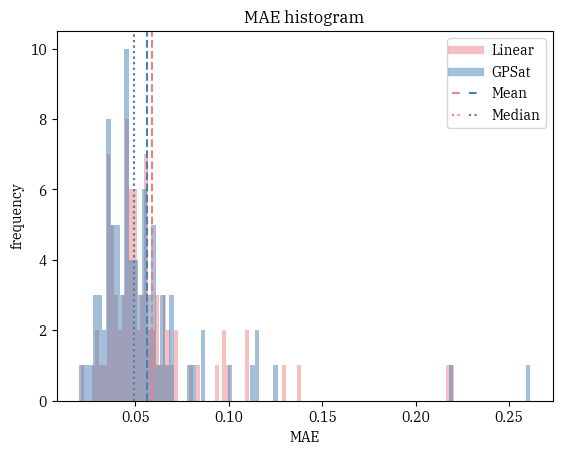

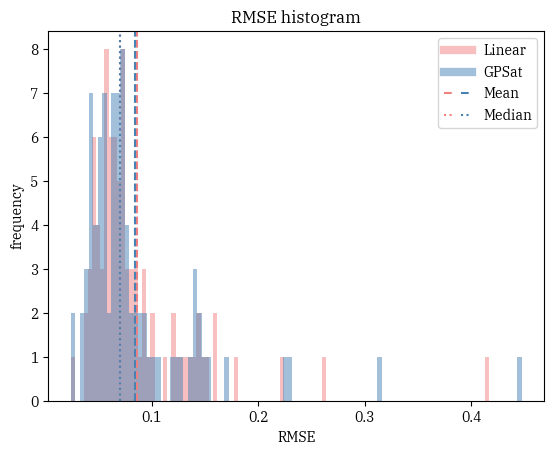

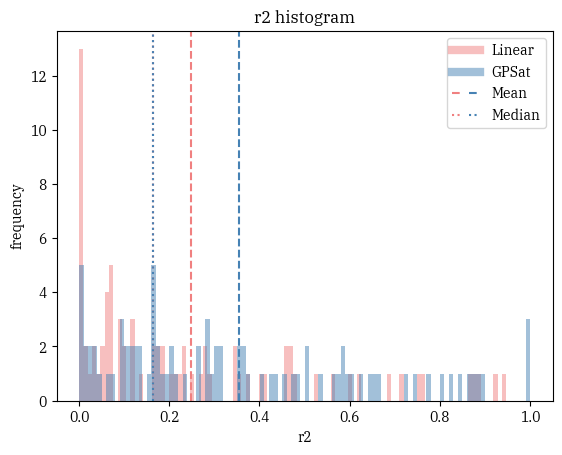

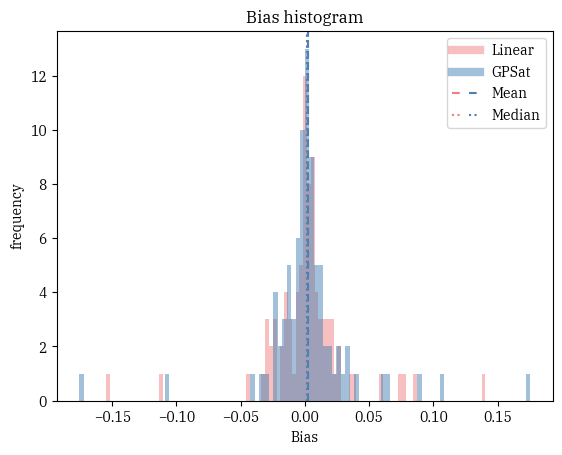

In [4]:
full_results_plot(metrics_df)

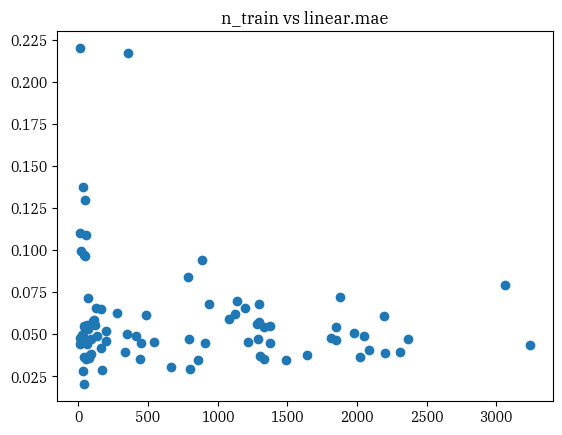

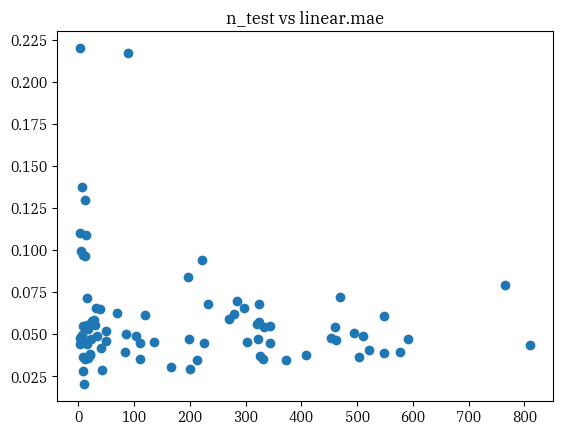

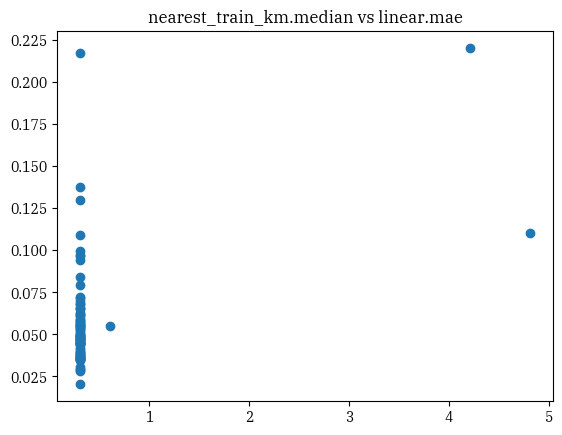

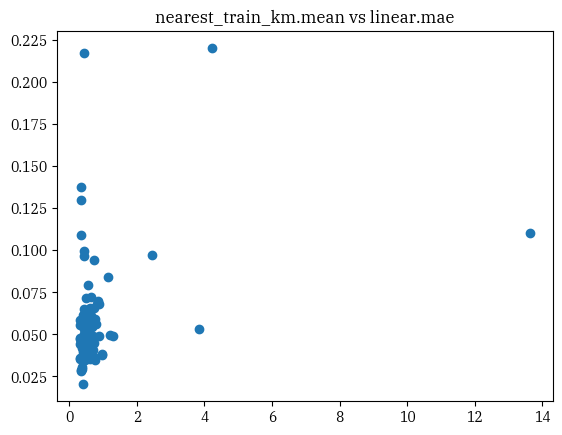

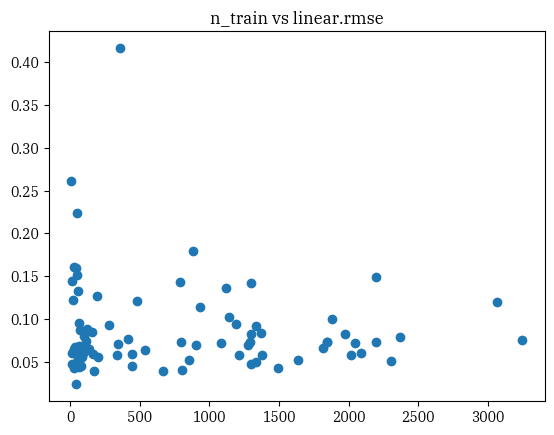

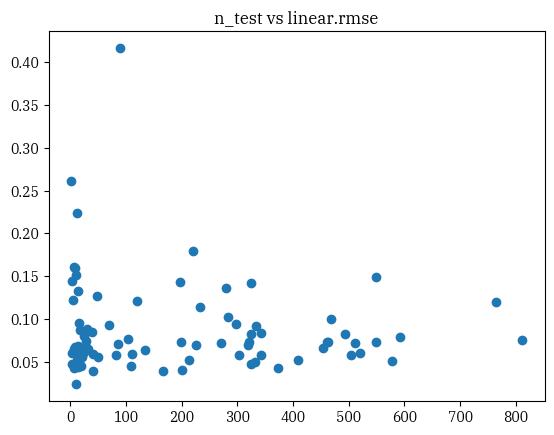

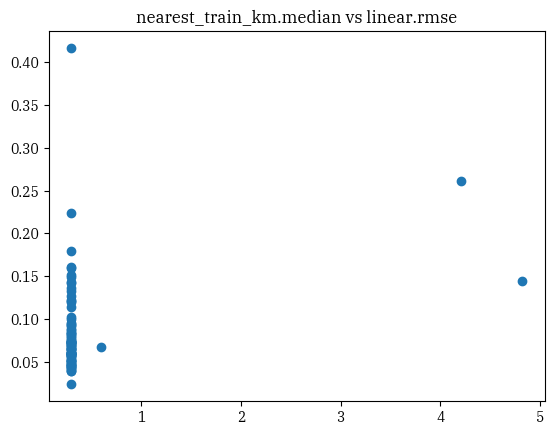

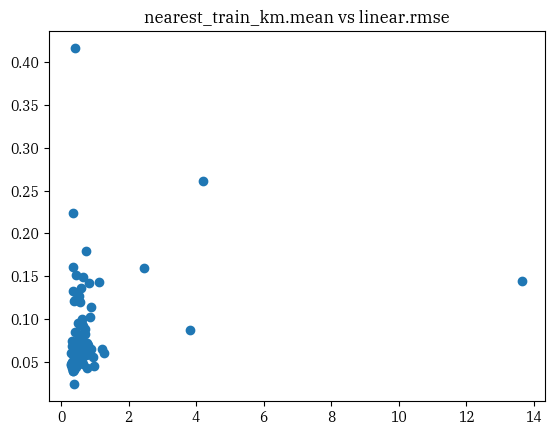

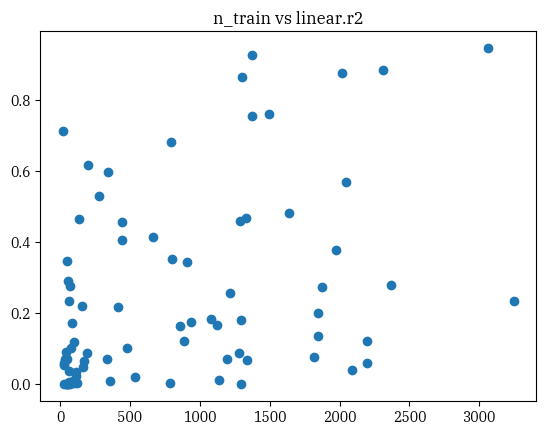

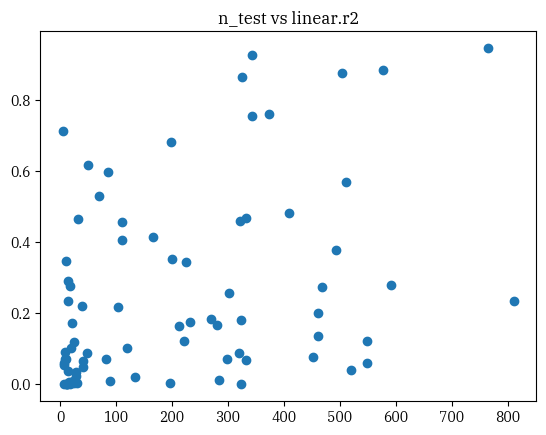

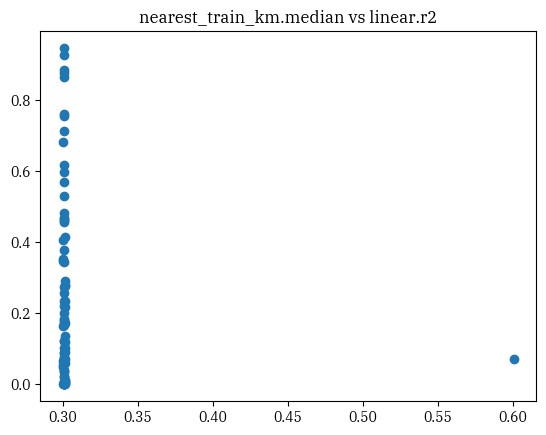

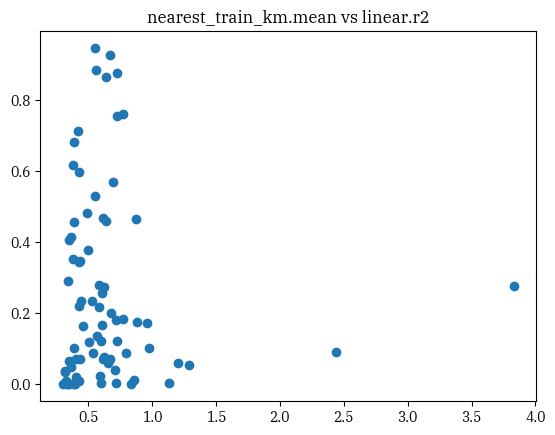

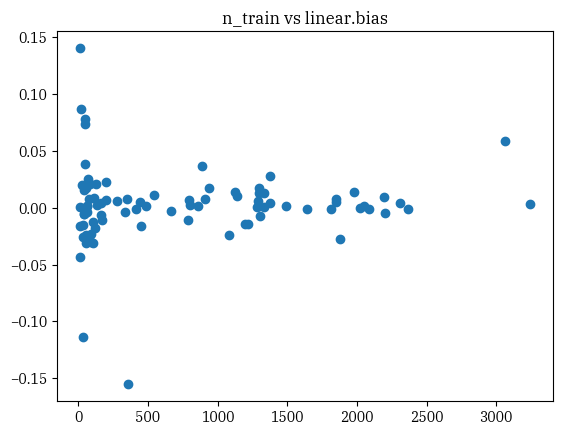

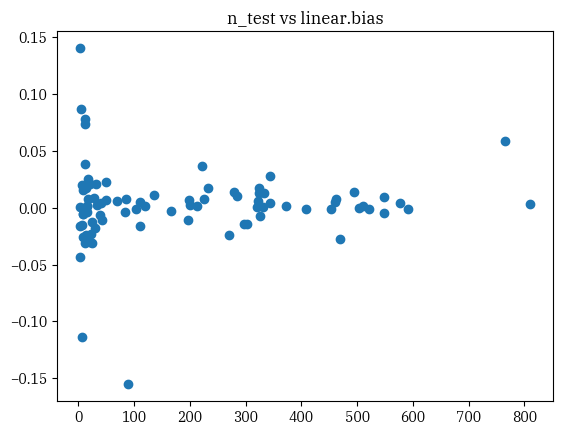

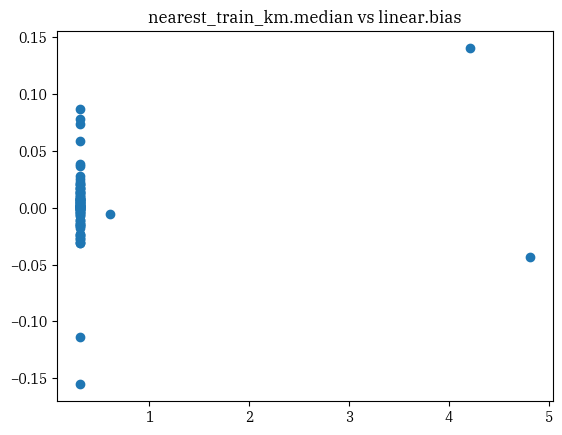

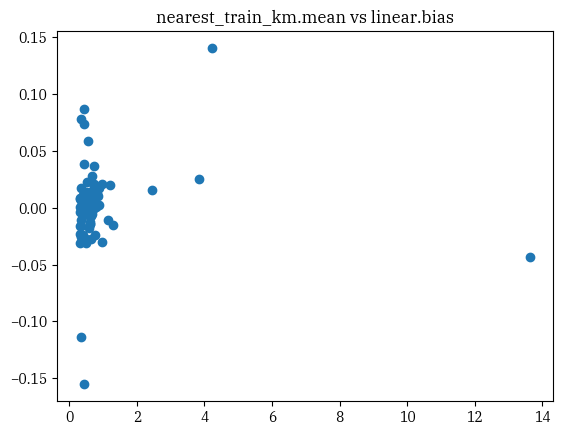

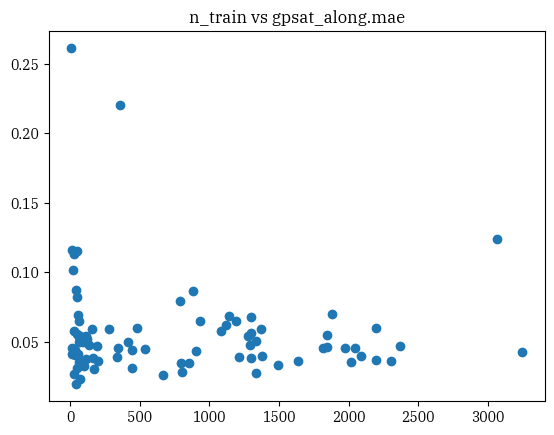

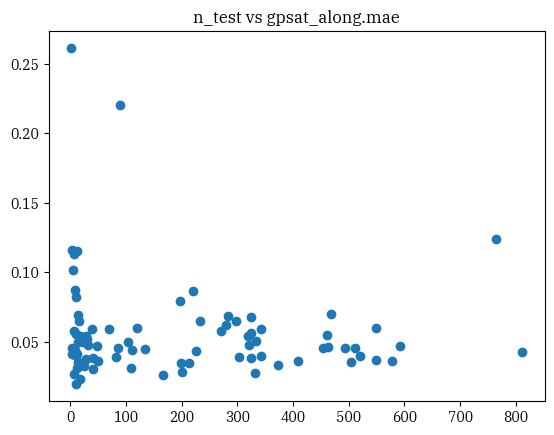

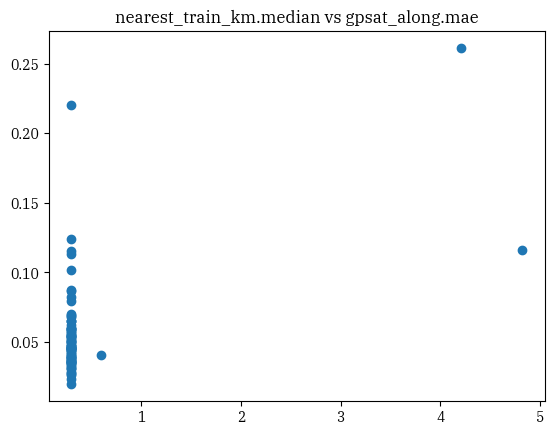

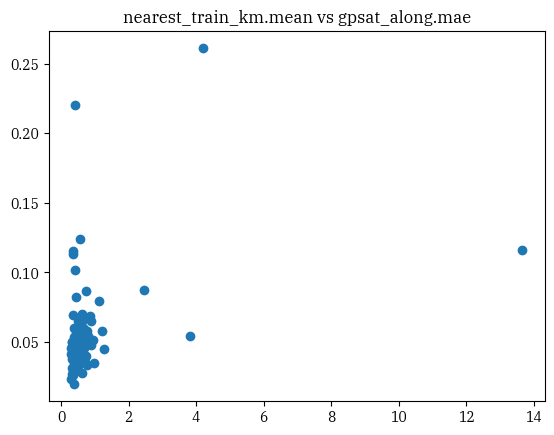

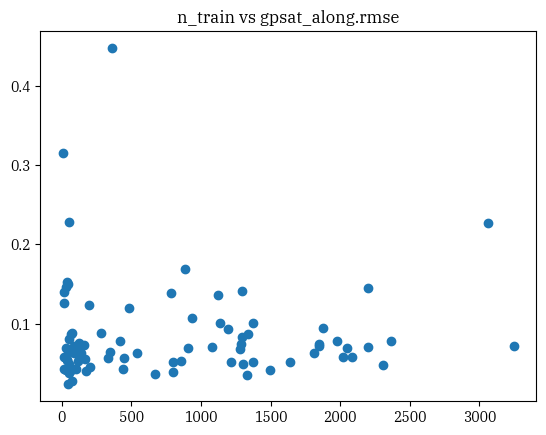

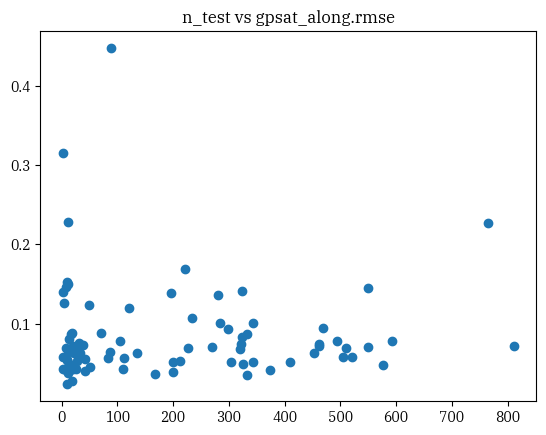

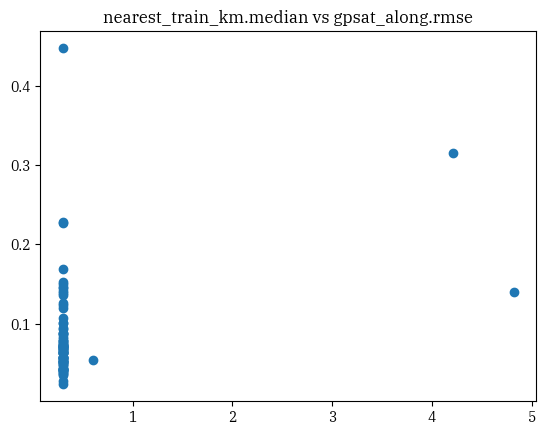

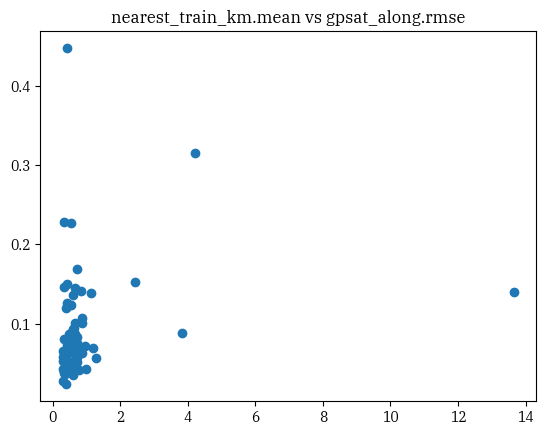

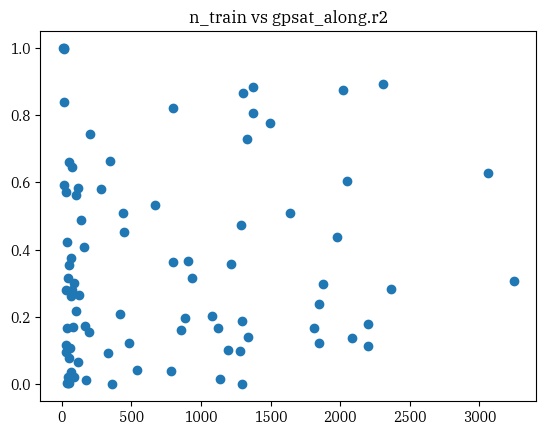

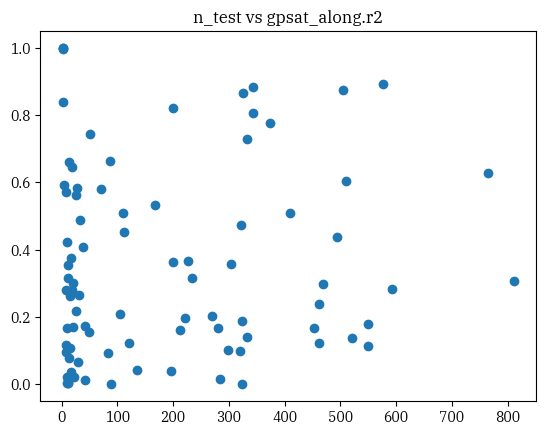

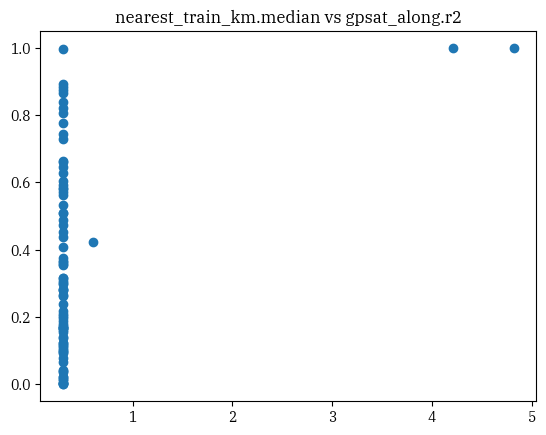

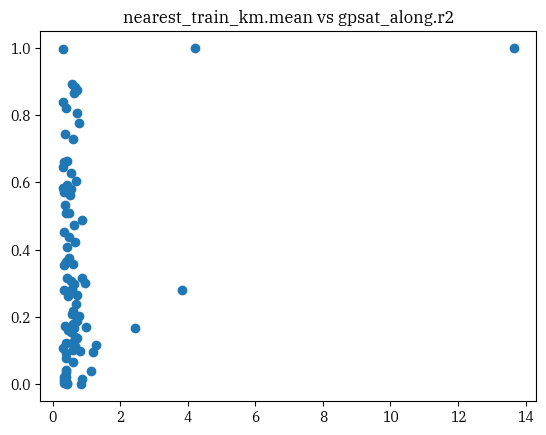

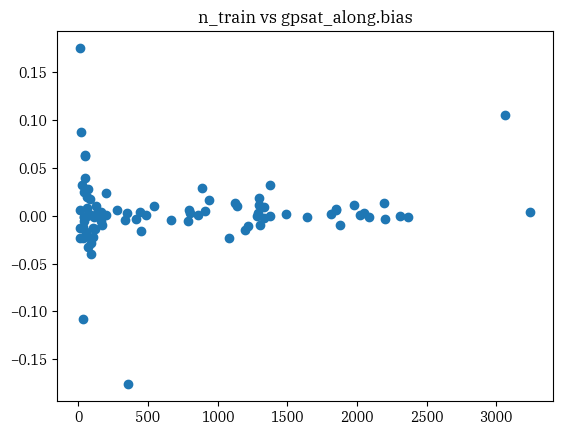

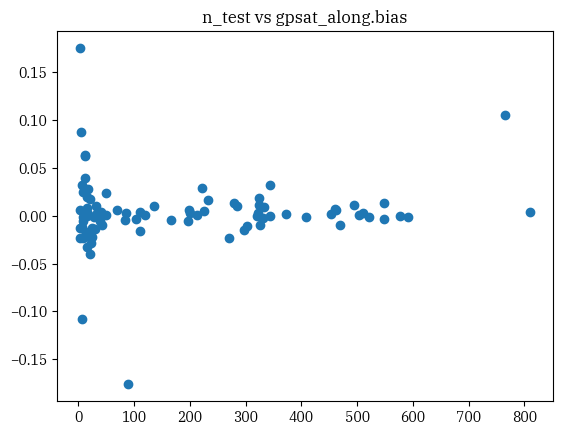

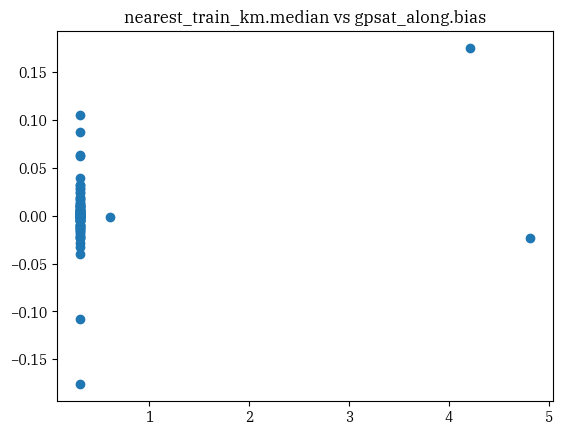

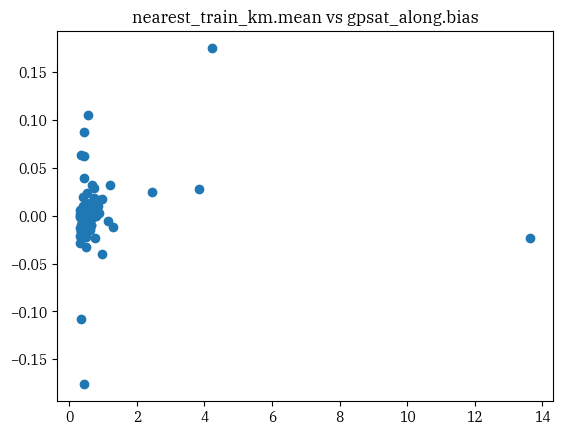

In [5]:
input_metrics = ['n_train', 'n_test', 'nearest_train_km.median', 'nearest_train_km.mean']
output_metrics = ['linear.mae', 'linear.rmse', 'linear.r2', 'linear.bias',
                  'gpsat_along.mae', 'gpsat_along.rmse', 'gpsat_along.r2', 'gpsat_along.bias']

for output_metric in output_metrics:
    for input_metric in input_metrics:
        compare_metrics(metrics_df, input_metric, output_metric)

Creating lead-based holdout plots...


/tmp/ipykernel_3095197/17506473.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax6.boxplot(box_data, labels=['Linear', 'GPSat'], patch_artist=True)


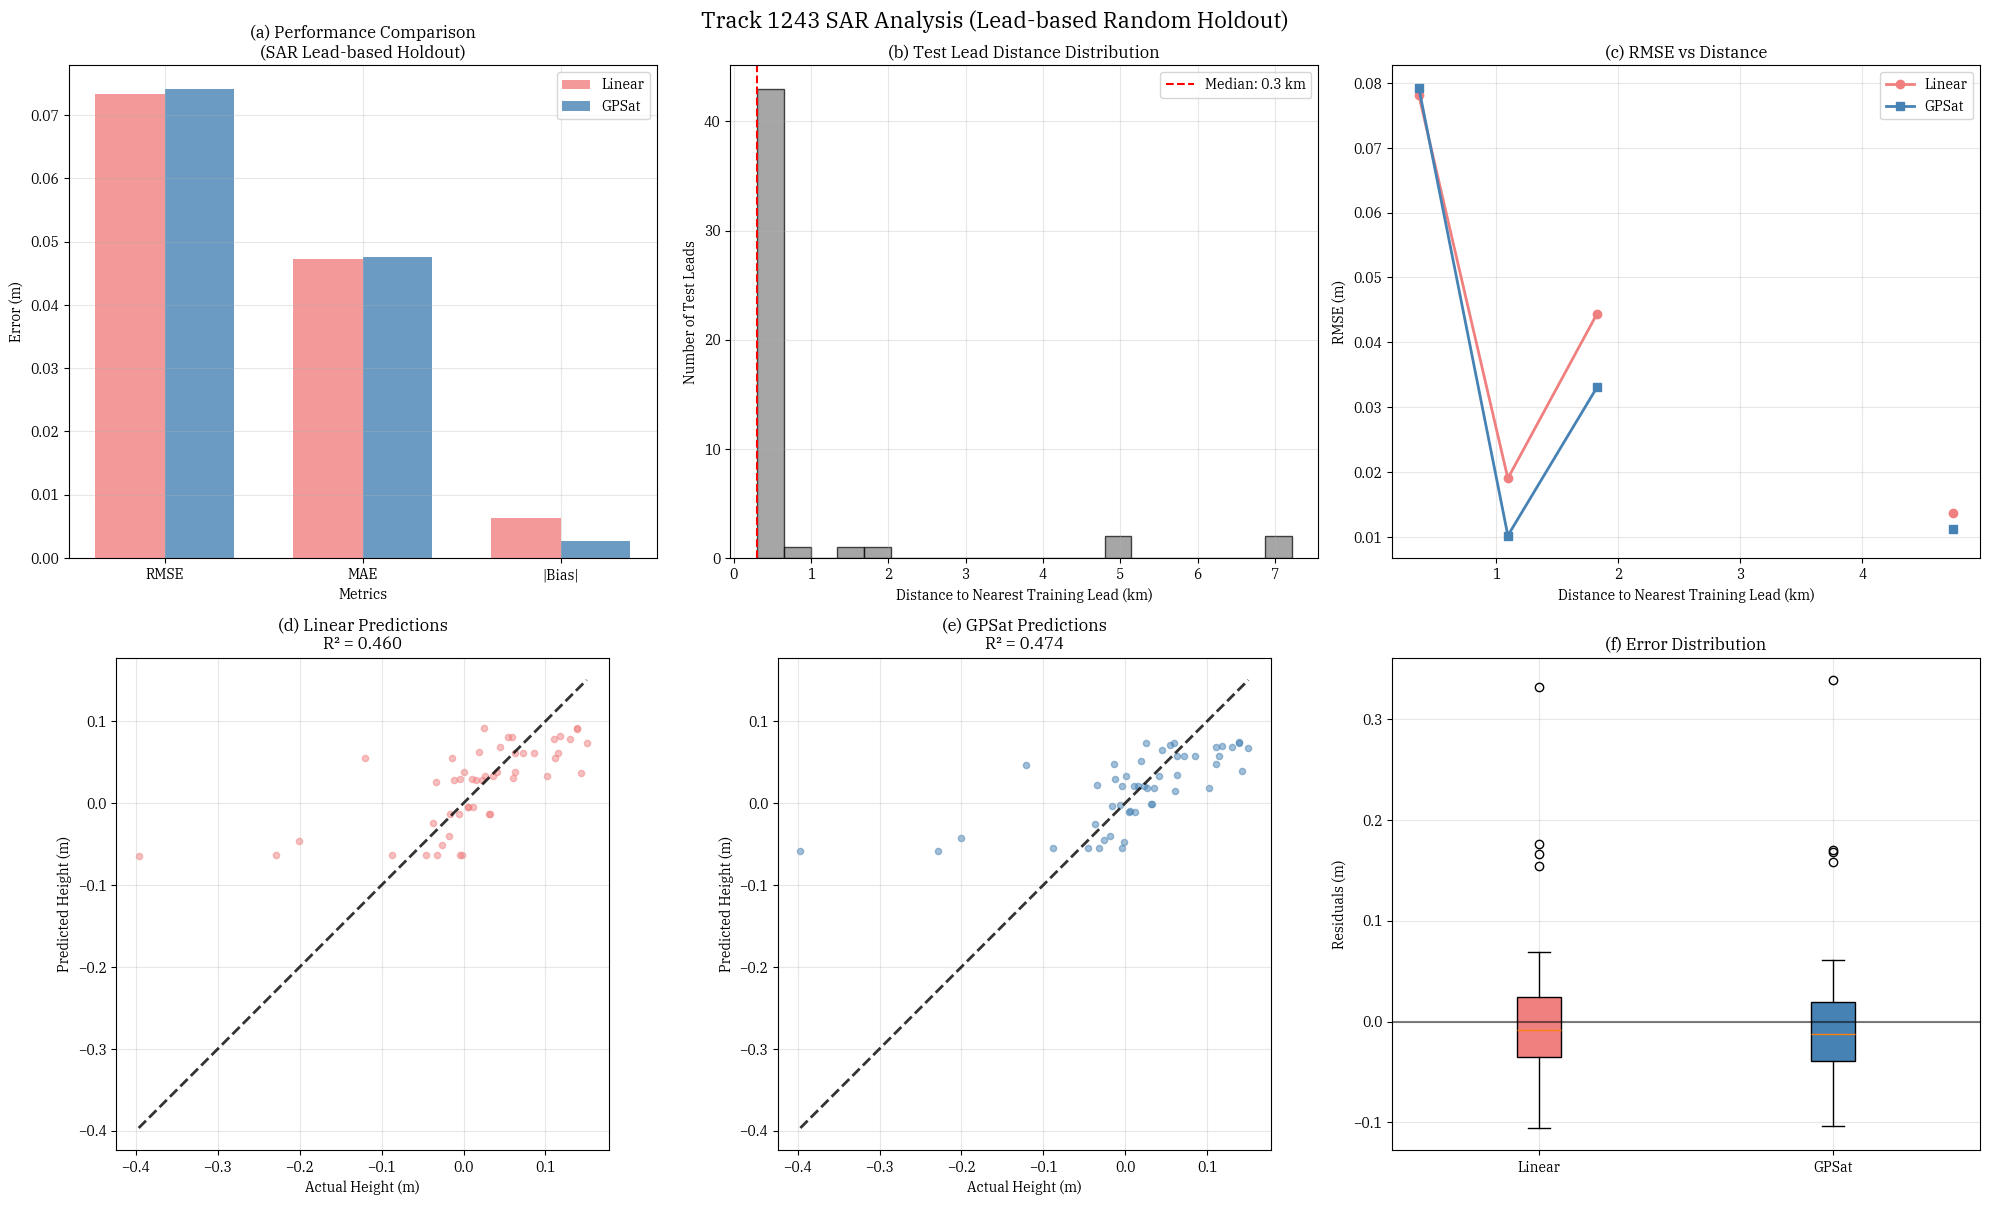

/home/mhen/miniconda3/envs/geol0069_gpsat/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


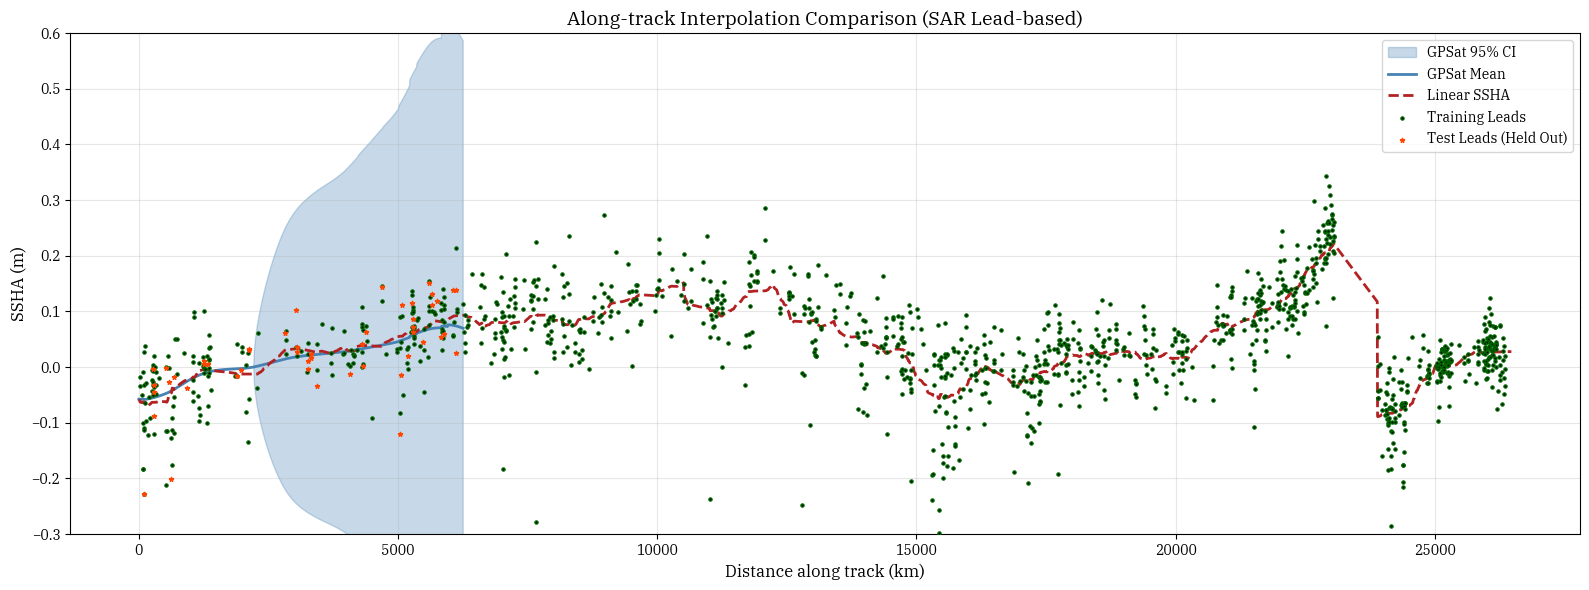

/tmp/ipykernel_3095197/17506473.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax6.boxplot(box_data, labels=['Linear', 'GPSat'], patch_artist=True)


(along-track visualization)
Creating lead-based holdout plots...


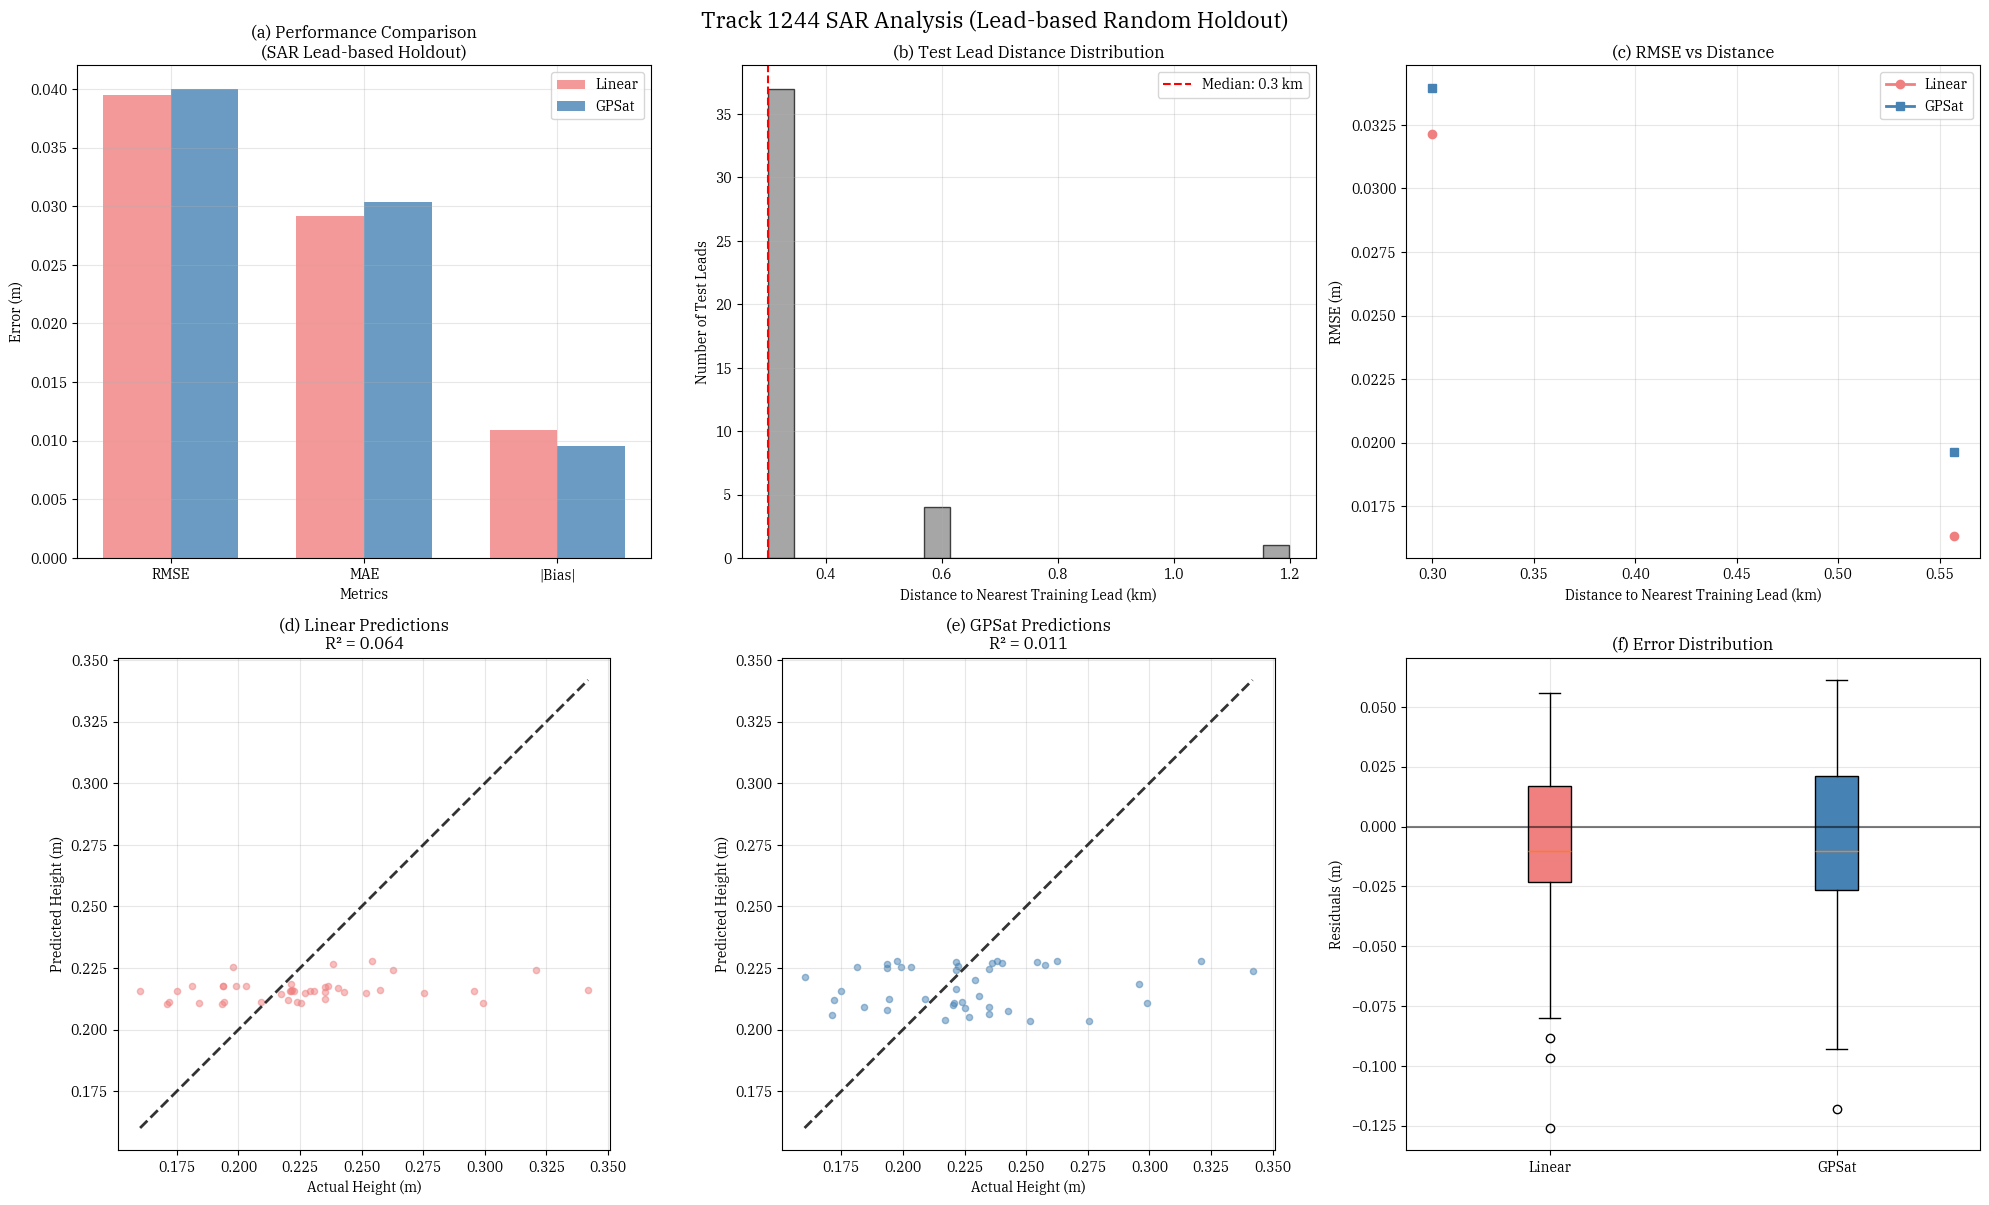

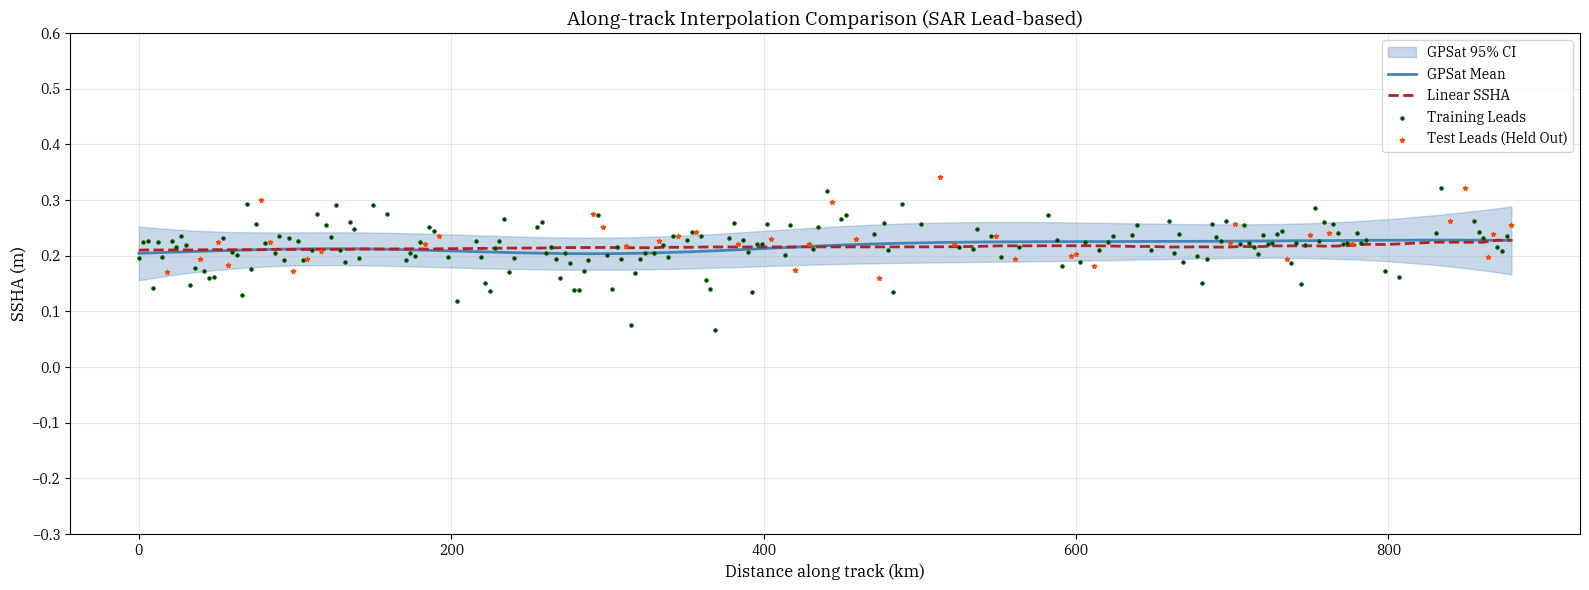

(along-track visualization)
Creating lead-based holdout plots...


/tmp/ipykernel_3095197/17506473.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax6.boxplot(box_data, labels=['Linear', 'GPSat'], patch_artist=True)


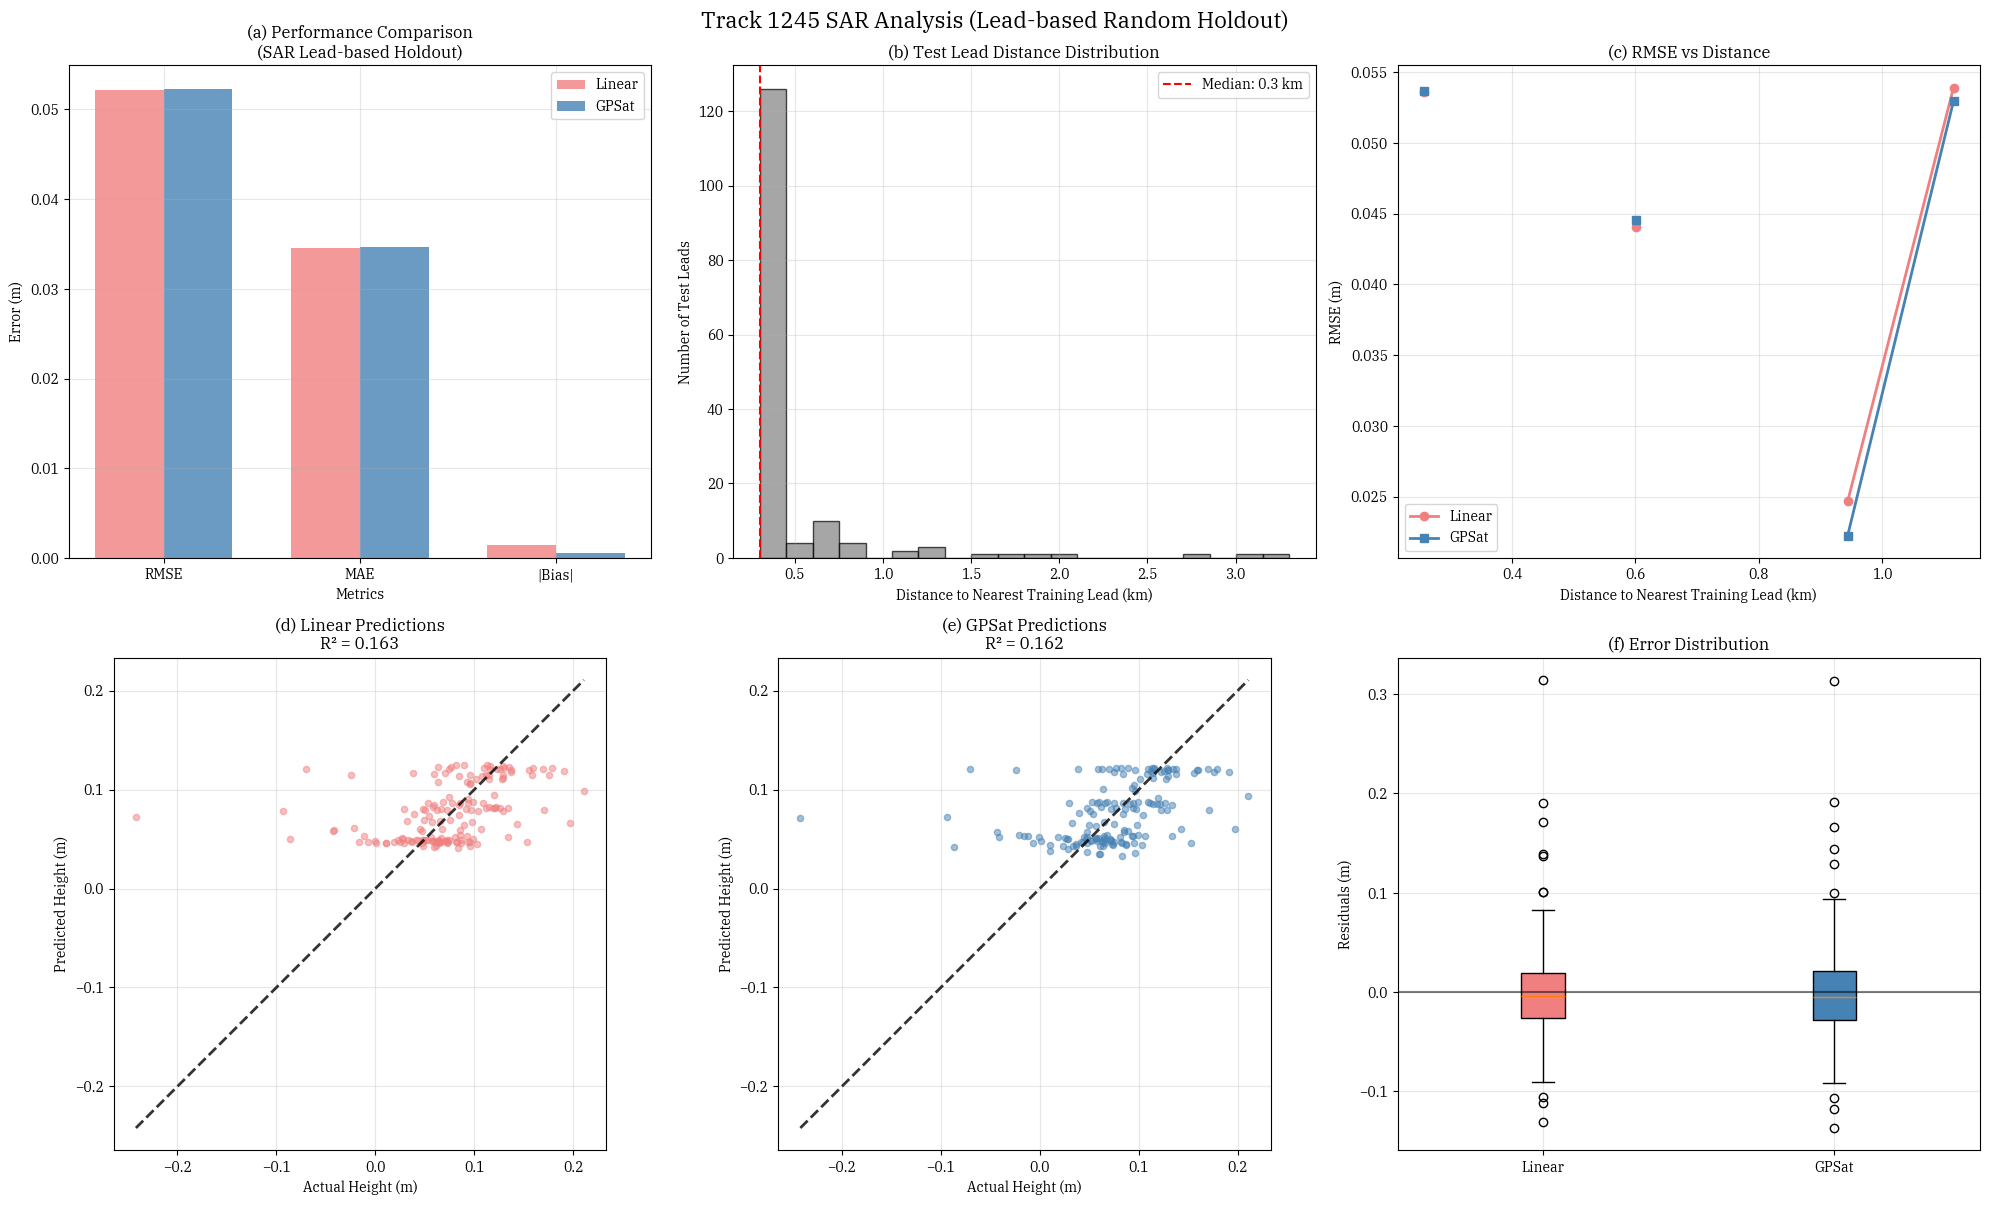

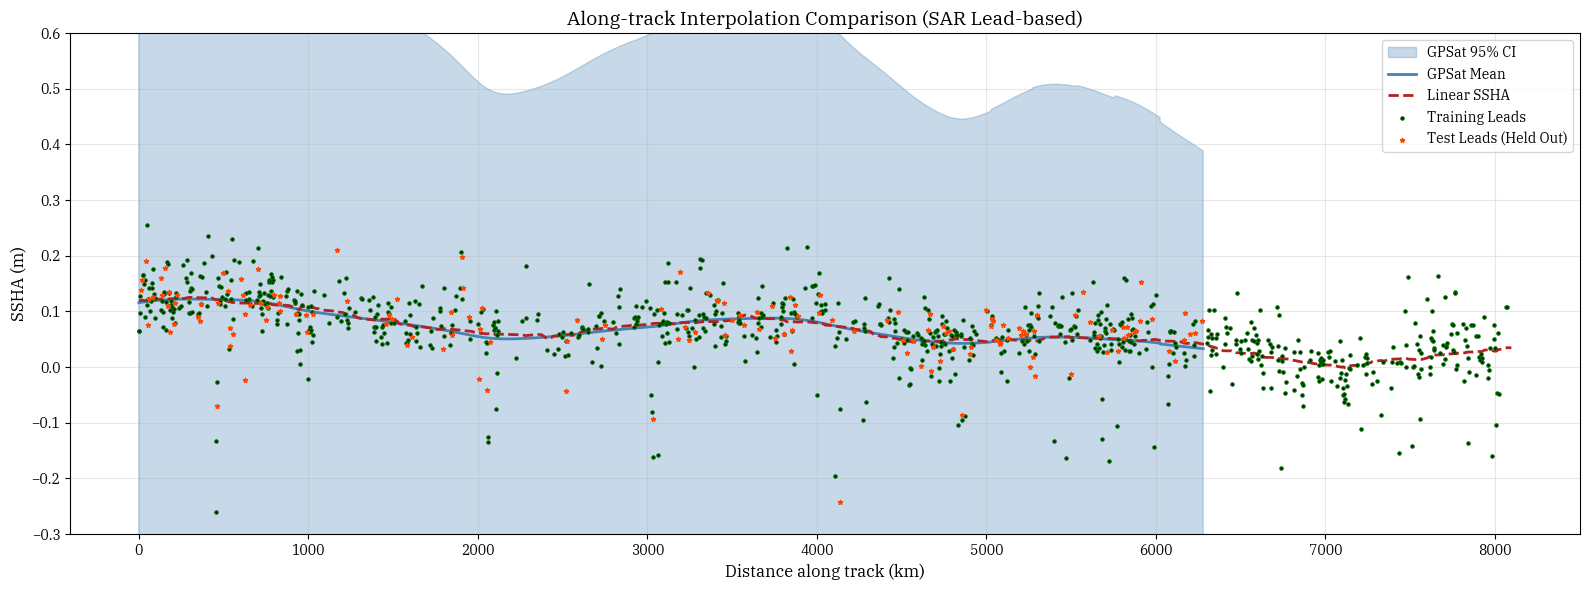

(along-track visualization)
Creating lead-based holdout plots...
Track 1246: Insufficient predictions for plotting
Creating lead-based holdout plots...
Track 1247: Insufficient predictions for plotting
Creating lead-based holdout plots...
Track 1248: Insufficient predictions for plotting
Creating lead-based holdout plots...


/tmp/ipykernel_3095197/17506473.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax6.boxplot(box_data, labels=['Linear', 'GPSat'], patch_artist=True)


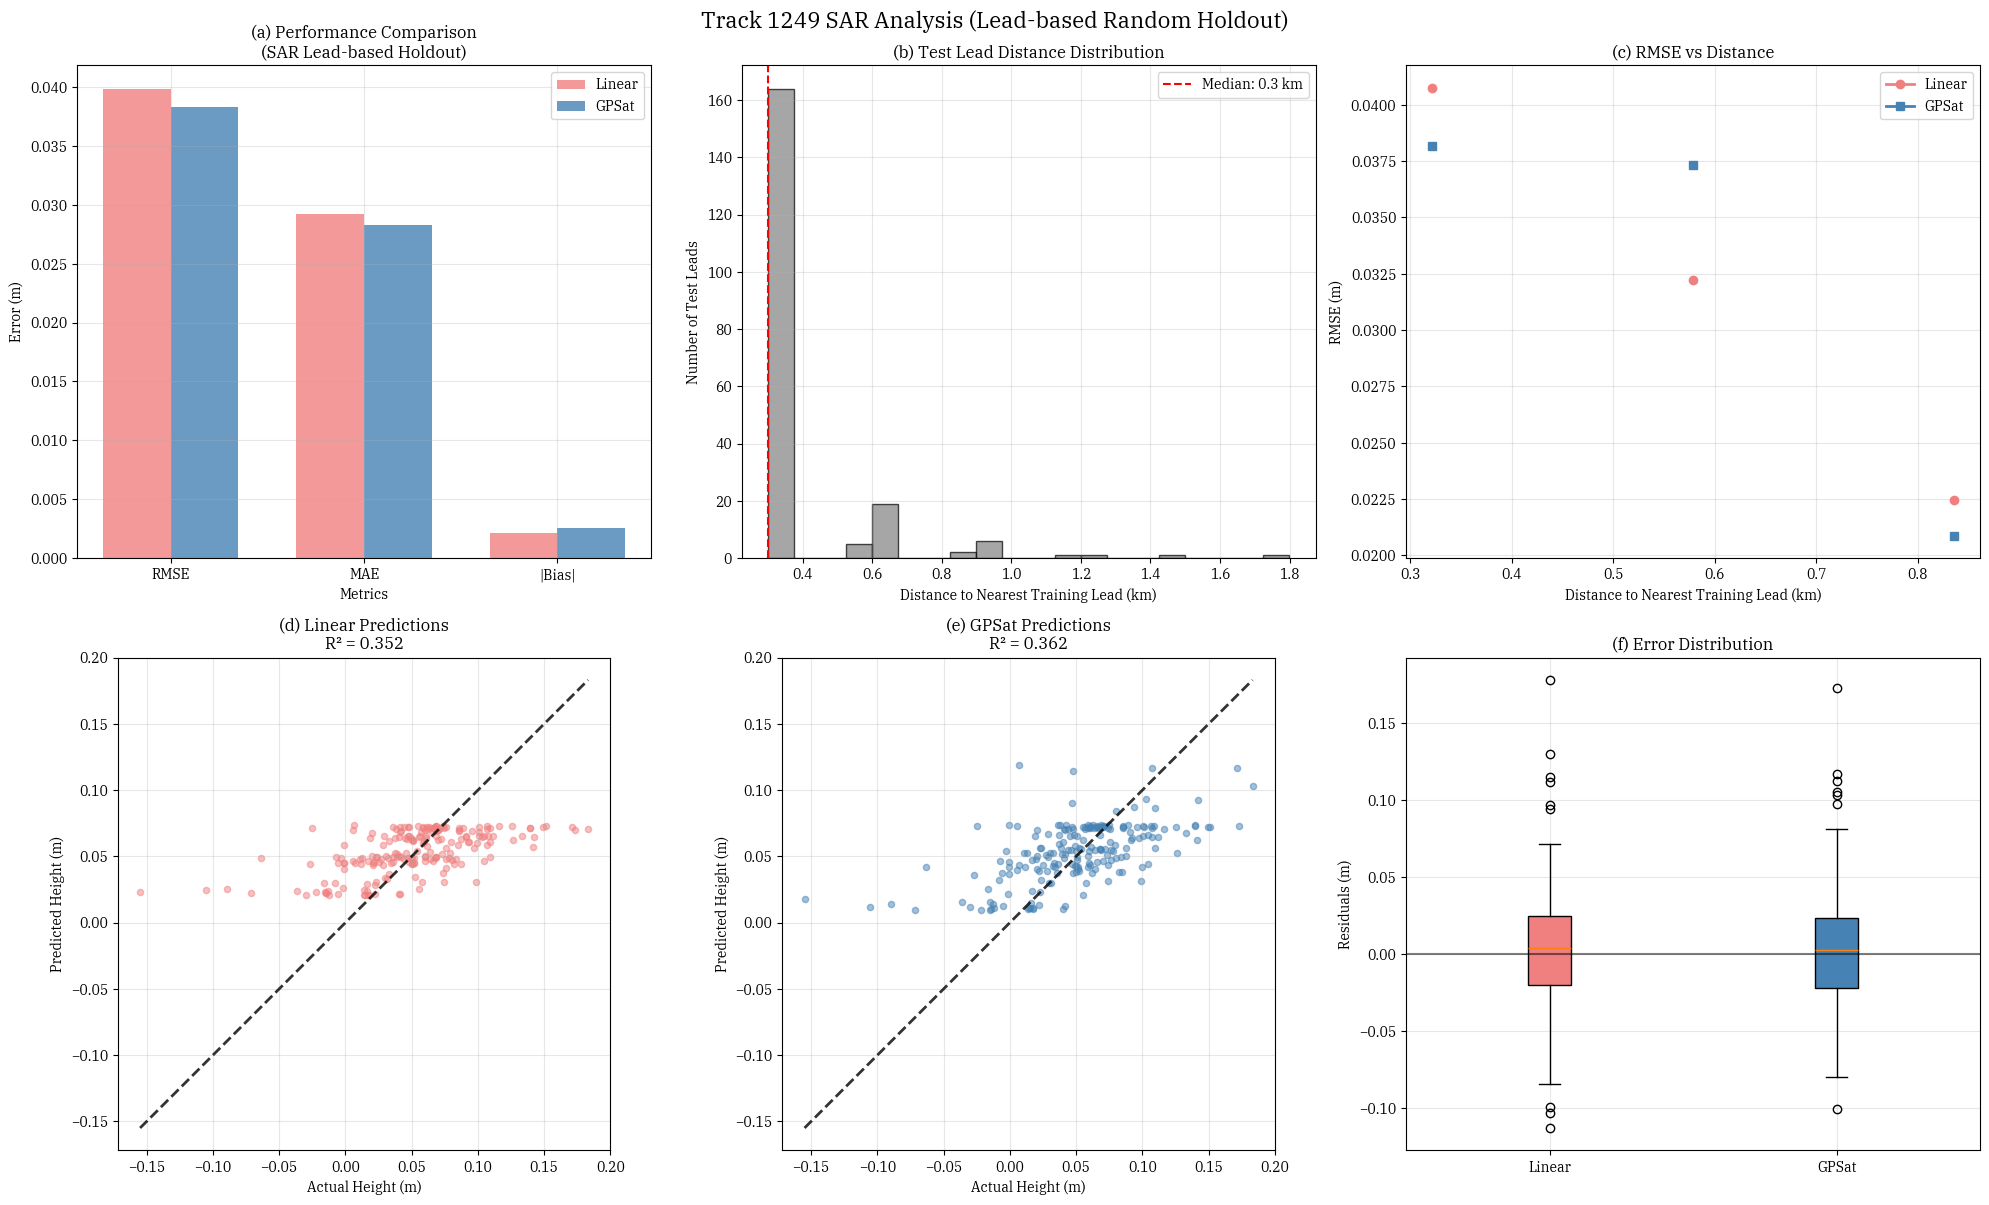

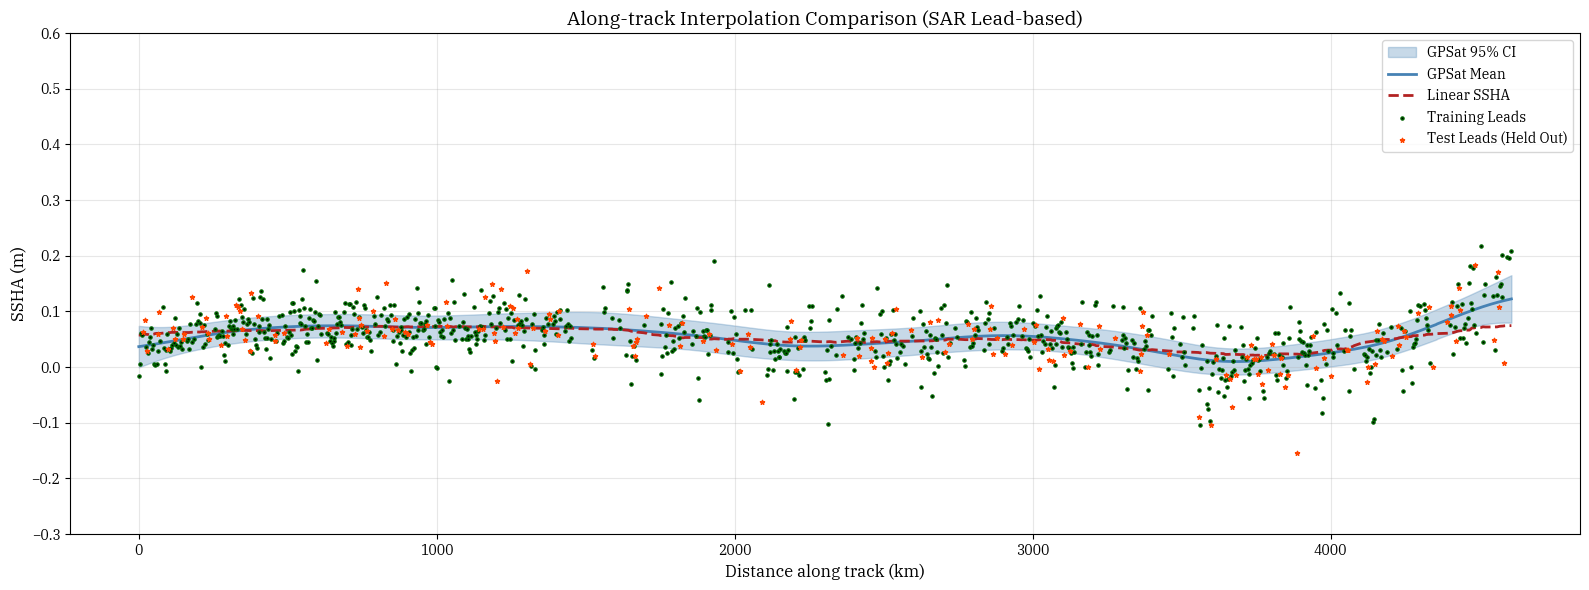

(along-track visualization)
Creating lead-based holdout plots...


/tmp/ipykernel_3095197/17506473.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax6.boxplot(box_data, labels=['Linear', 'GPSat'], patch_artist=True)


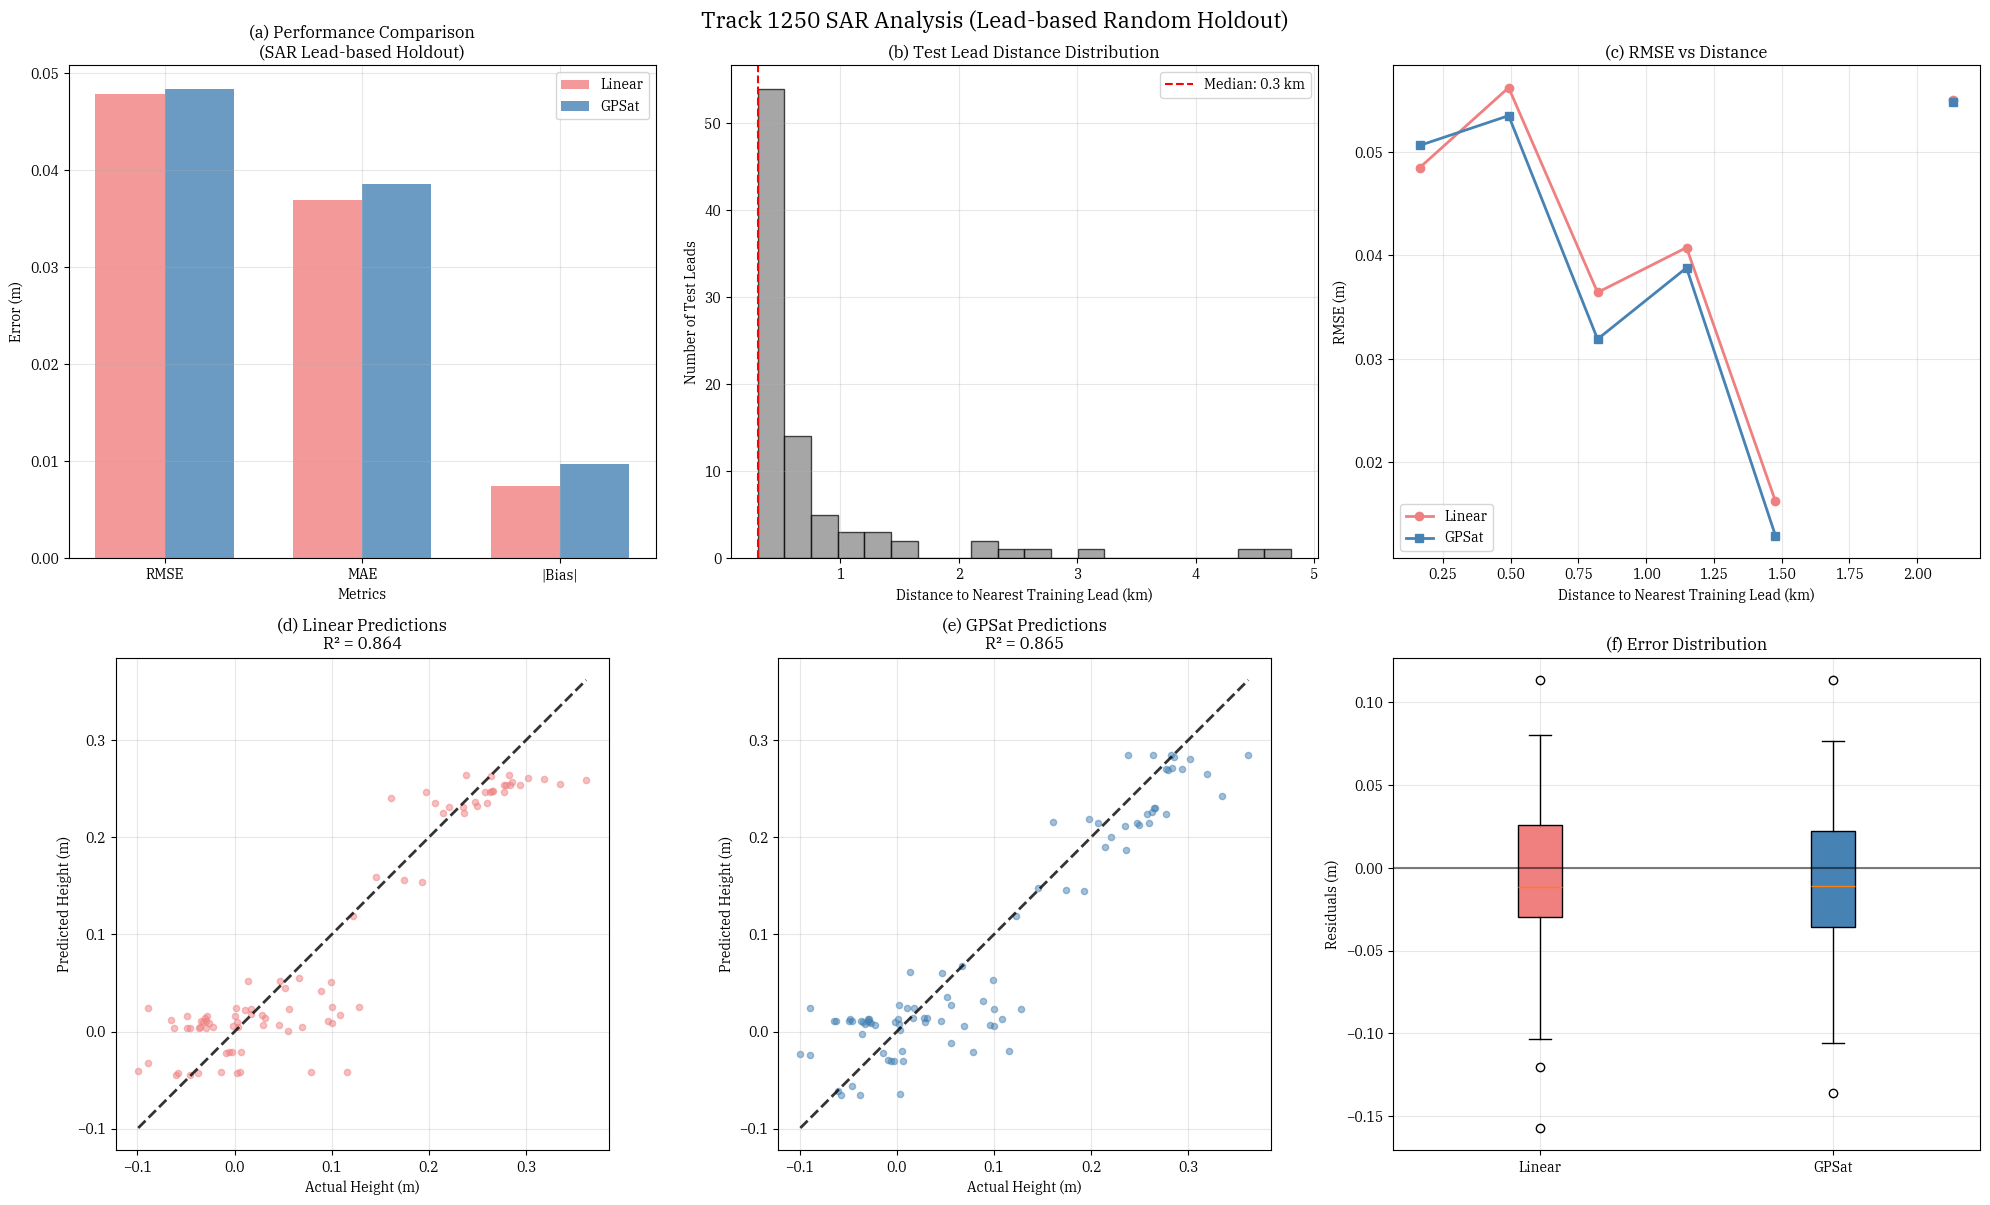

/home/mhen/miniconda3/envs/geol0069_gpsat/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


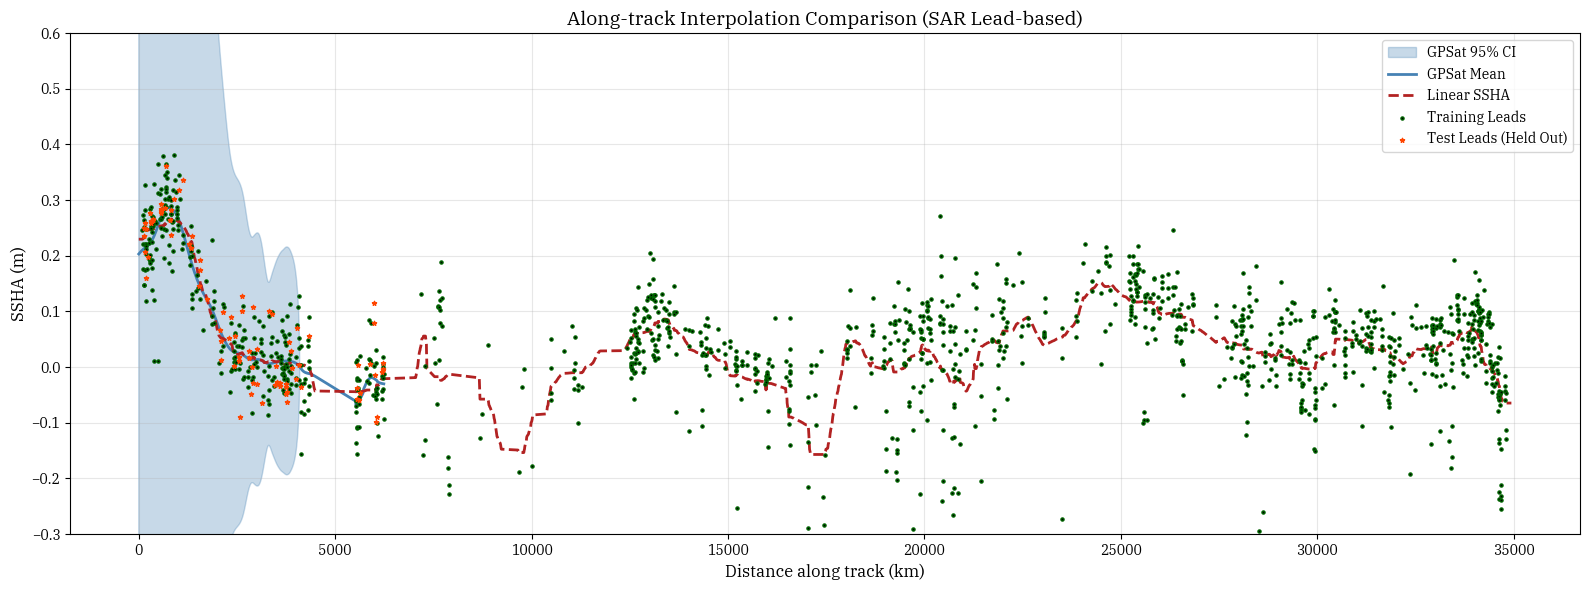

/tmp/ipykernel_3095197/17506473.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax6.boxplot(box_data, labels=['Linear', 'GPSat'], patch_artist=True)


(along-track visualization)
Creating lead-based holdout plots...


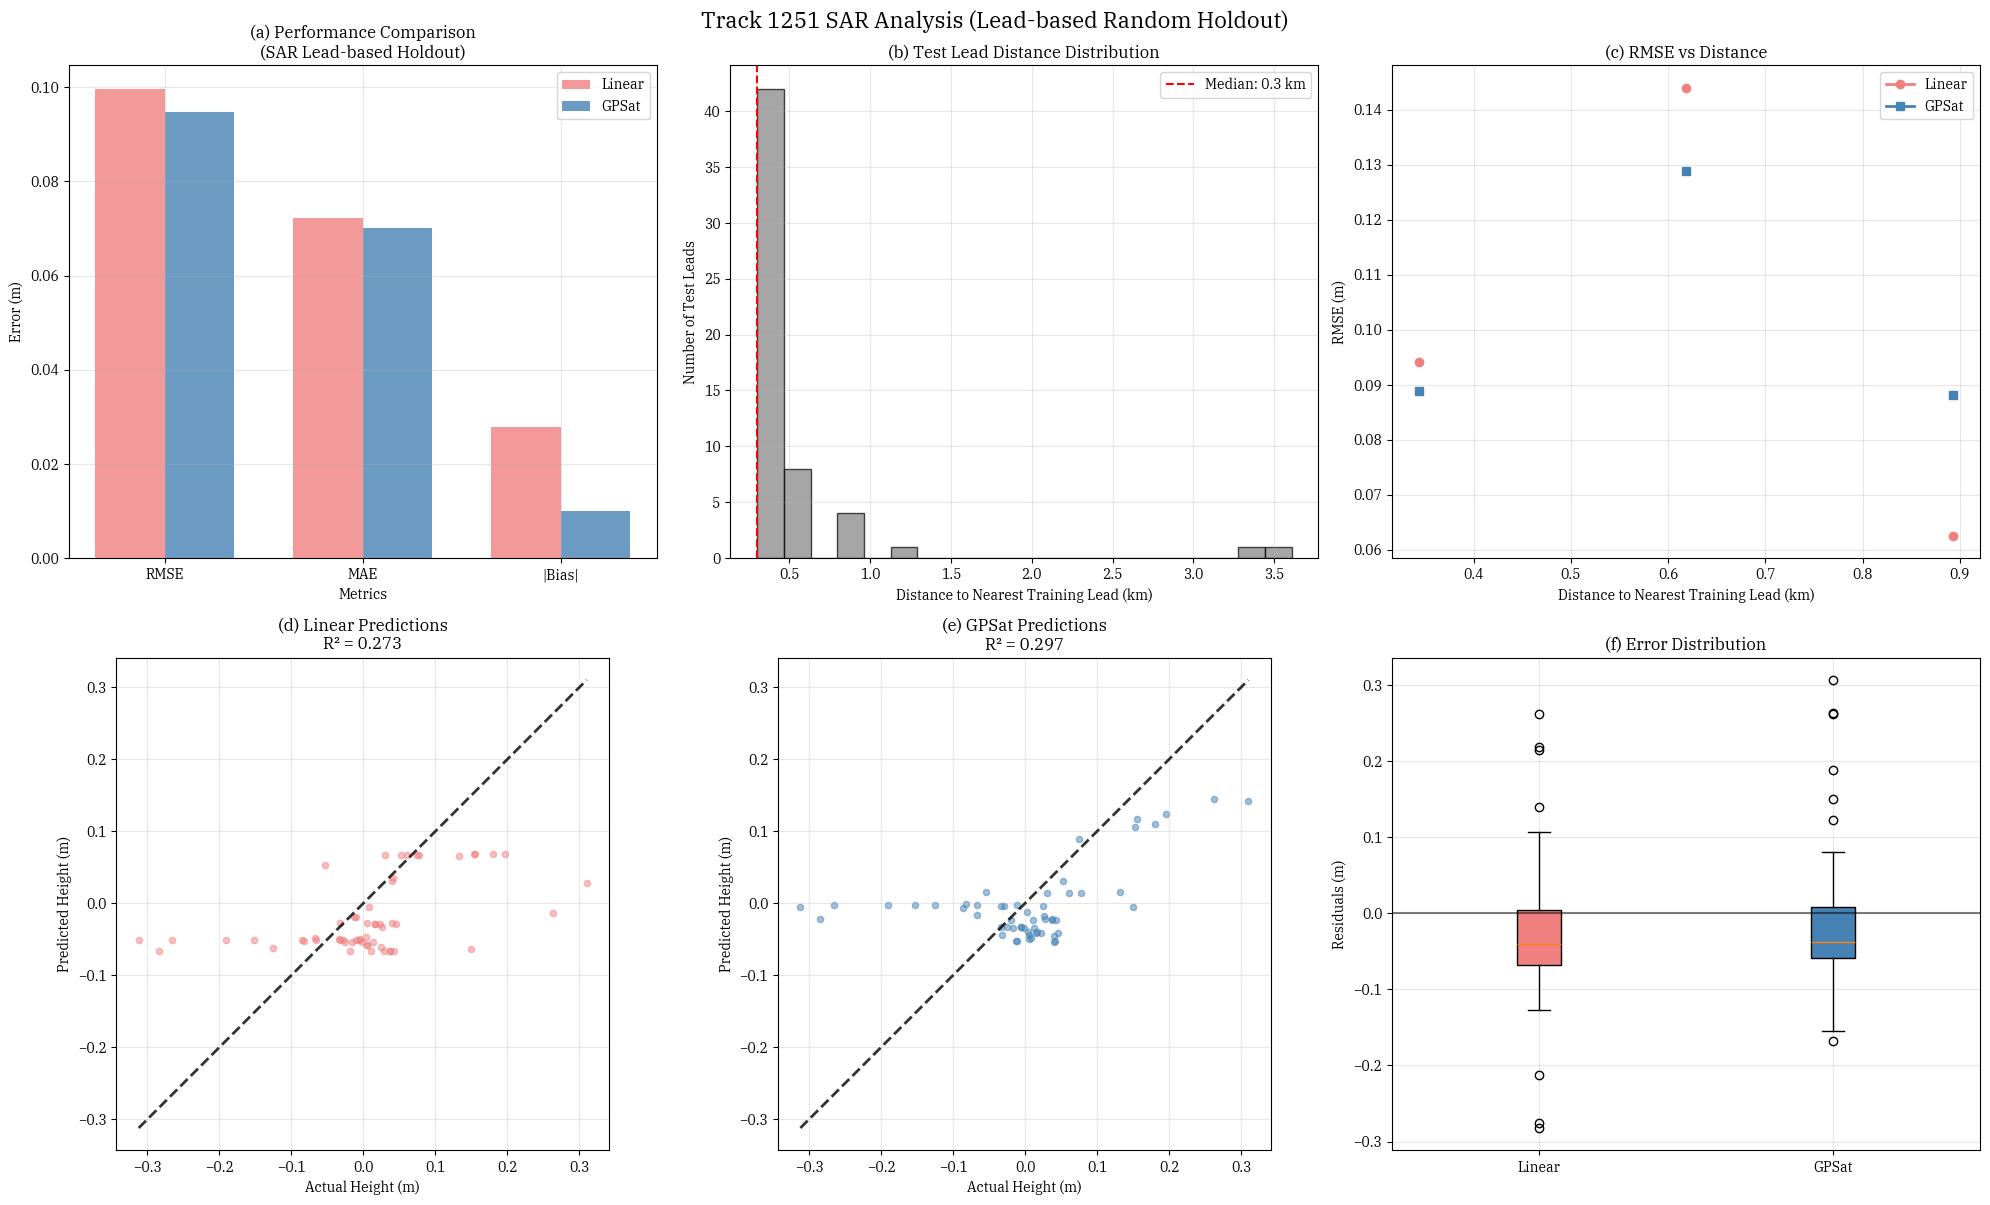

/home/mhen/miniconda3/envs/geol0069_gpsat/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


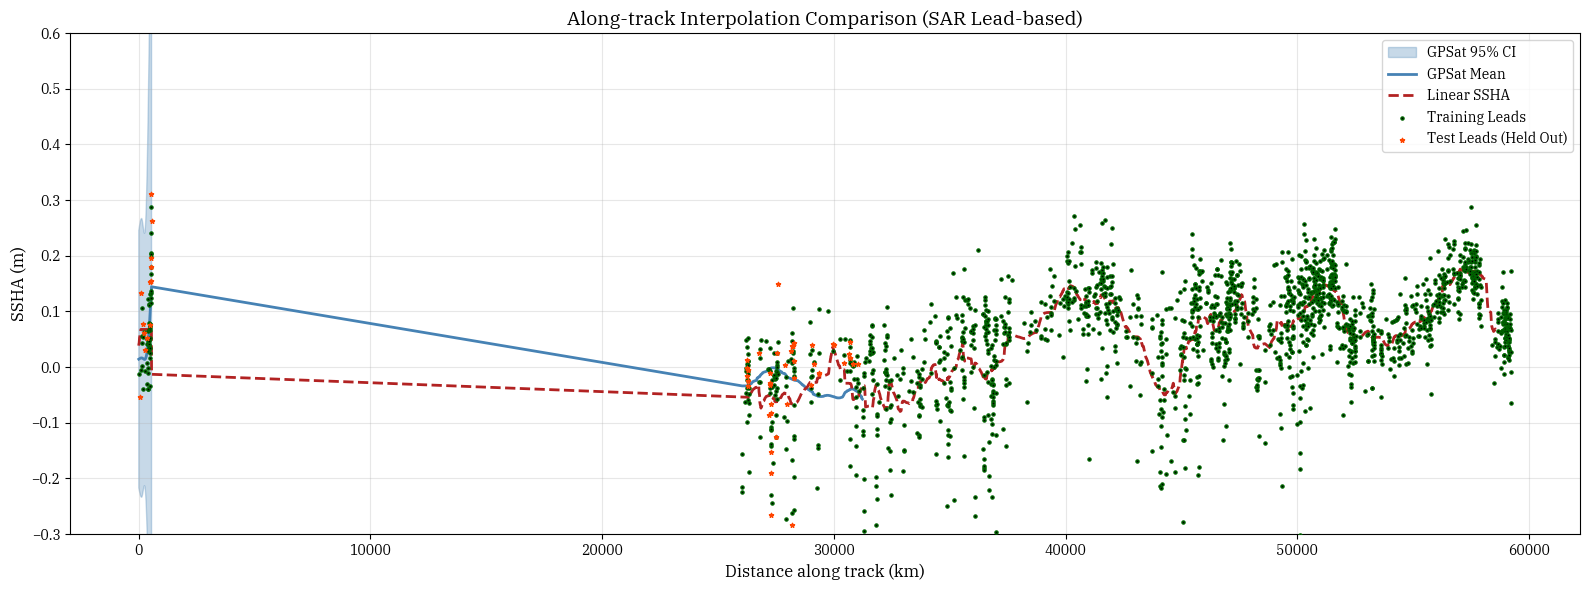

/tmp/ipykernel_3095197/17506473.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax6.boxplot(box_data, labels=['Linear', 'GPSat'], patch_artist=True)


(along-track visualization)
Creating lead-based holdout plots...


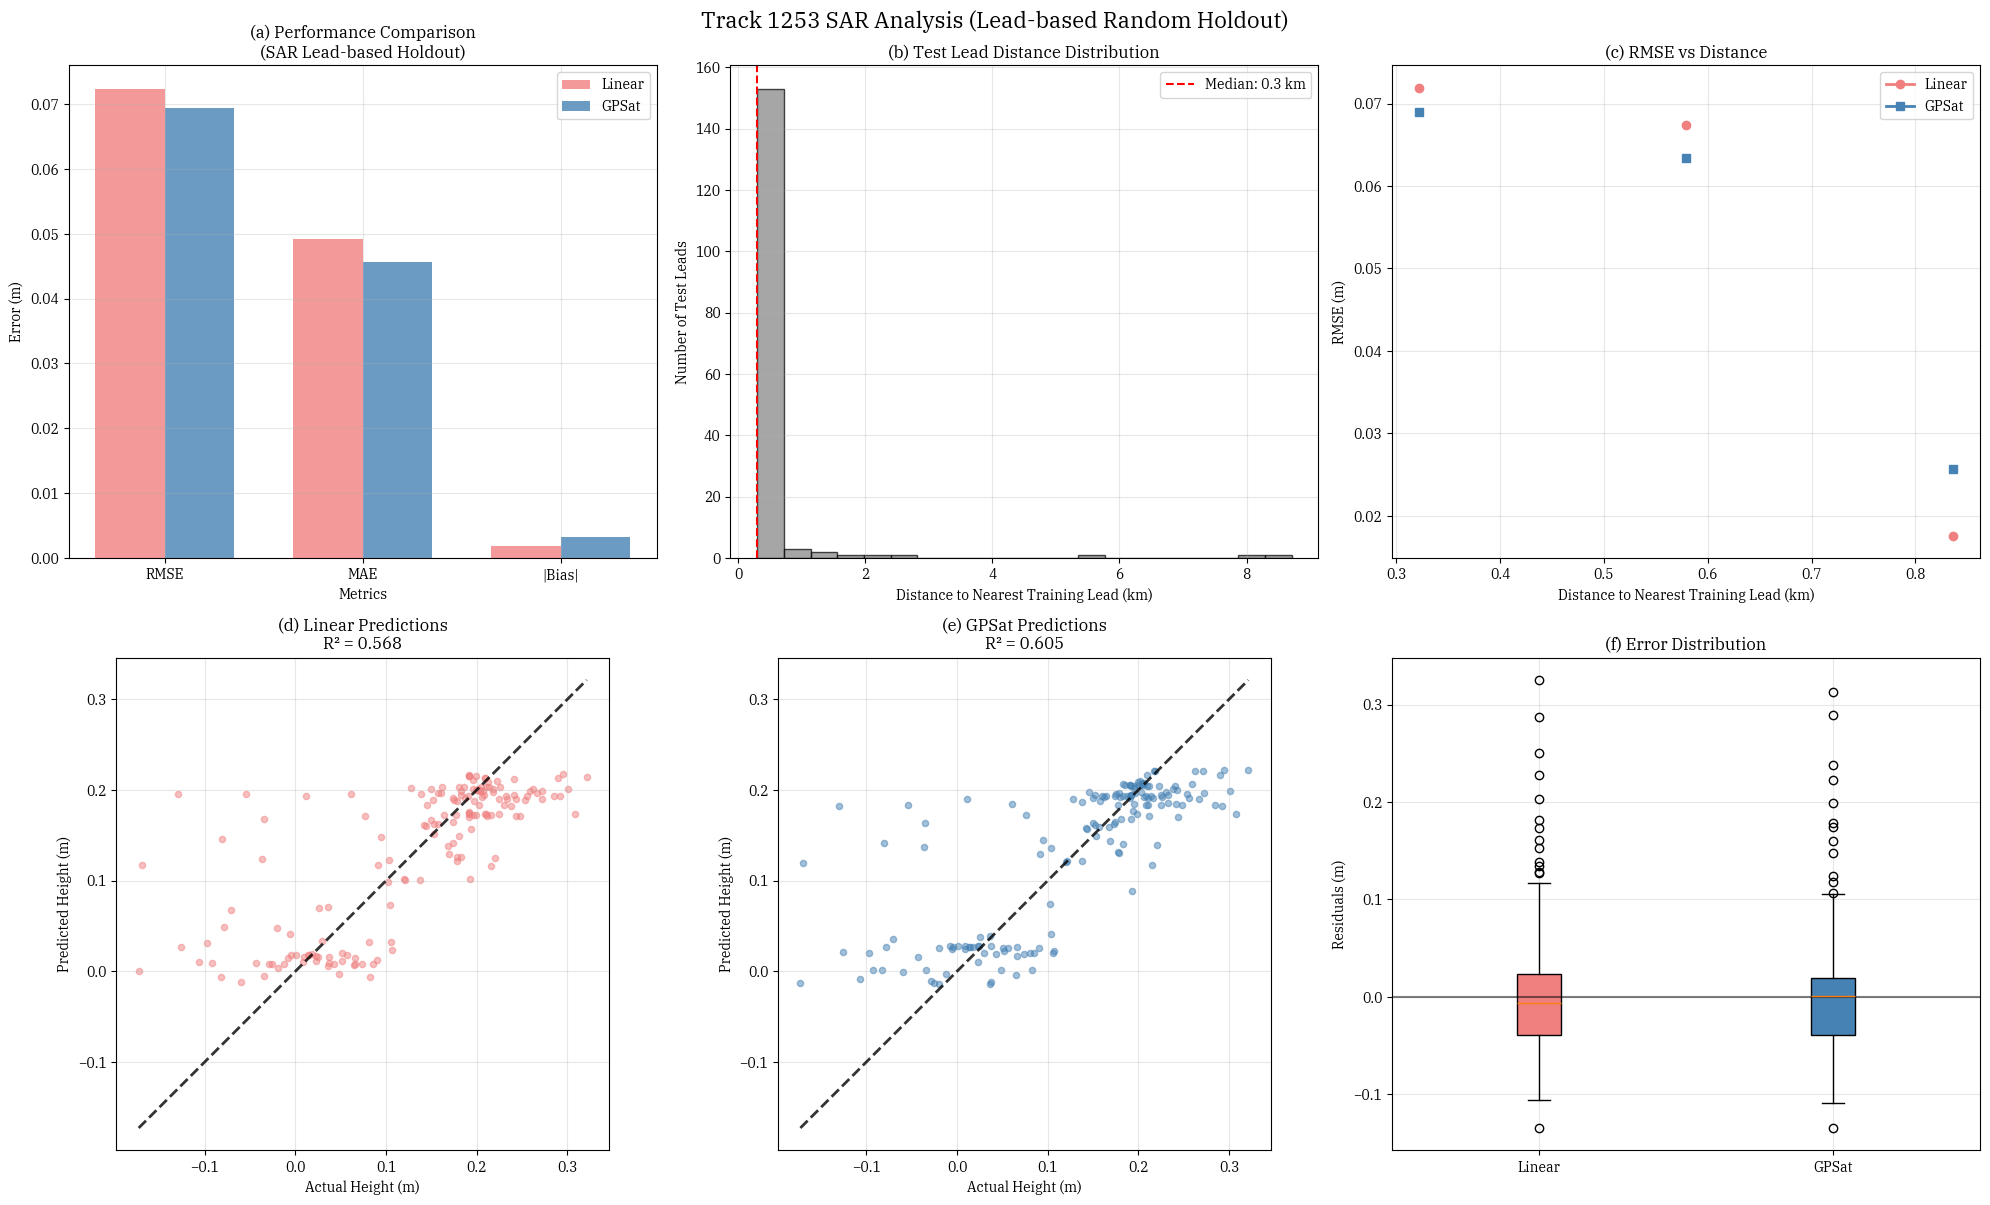

/home/mhen/miniconda3/envs/geol0069_gpsat/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


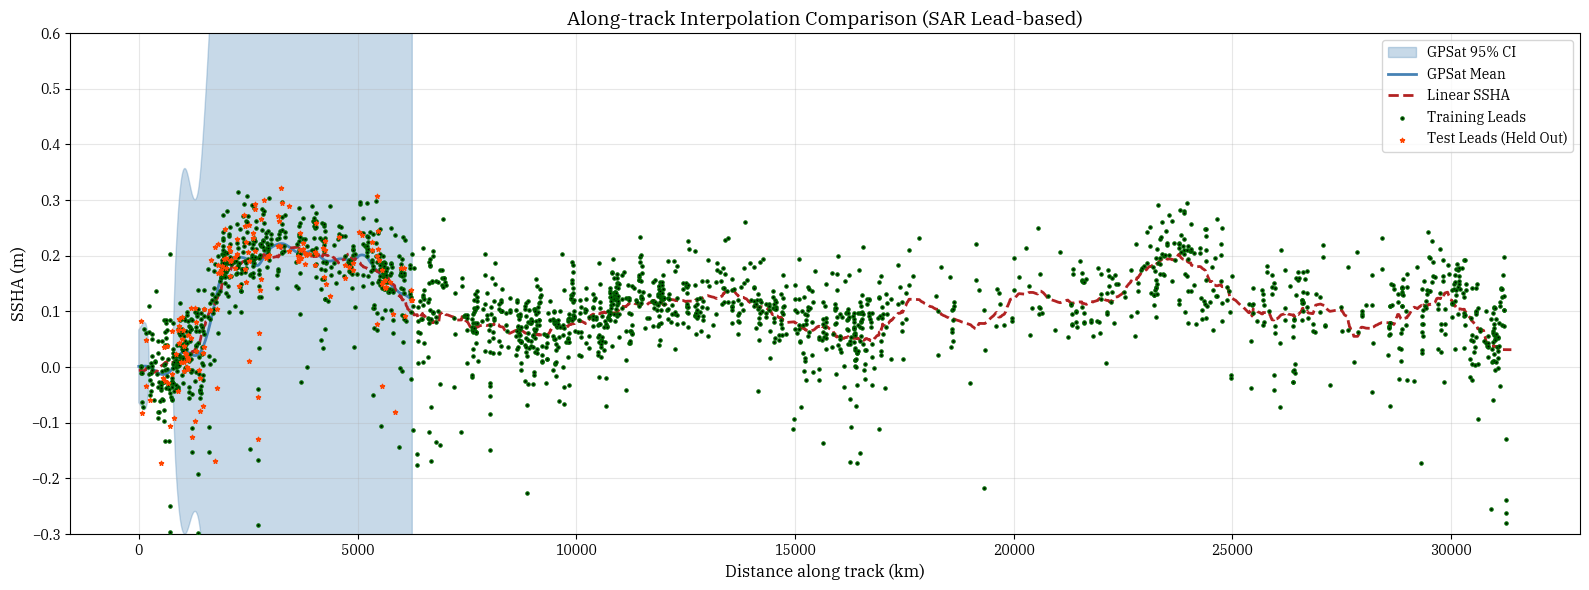

(along-track visualization)


In [6]:
tracks = results_df['track'].unique()
for track in tracks[:10]:
    create_single_lead_plot(plot_data_df, results_df, metrics_df, track)